In [1]:
import torch 

torch.cuda.is_available()

True

### Reading raw job logs + initial analysis

In [3]:
import os
import glob
import time
import polars as pl

# 1. Direct path setup
RAW_DIR = "/media/storage0/allison/BatchSystem-2025"

# Find all 32 partition files directly in RAW_DIR
valid_paths = sorted(glob.glob(os.path.join(RAW_DIR, "fife_raw_part_*.parquet")))
print(f"Found {len(valid_paths)} Parquet partition files.")
assert valid_paths, f"No files found in {RAW_DIR} matching 'fife_raw_part_*.parquet'!"

# Calculate dataset size on disk
total_gb = sum(os.path.getsize(p) for p in valid_paths) / 1e9
print(f"Total dataset size on disk: {total_gb:.2f} GB across {len(valid_paths)} files.")

# 2. Columns to extract
NEED = [
    "ExitCode","ExitSignal","JobStatus","RemoveReason","LastHoldReason","LastHoldReasonCode",
    "NumJobStarts","QDate","JobStartDate","JobCurrentStartDate","JobCurrentStartExecutingDate",
    "CompletionDate","RemoteWallClockTime","x509UserProxyExpiration","Owner","AccountingGroup",
    "Group","POMS4_CAMPAIGN_ID","POMS4_CAMPAIGN_NAME","POMS4_CAMPAIGN_STAGE_NAME",
    "POMS4_CAMPAIGN_STAGE_ID","POMS4_CAMPAIGN_TYPE","POMS4_TEST_LAUNCH","Jobsub_Group",
    "SingularityImage","Blacklist_Sites","RequestCpus","RequestDisk","RequestMemory","RequestSlots",
    "CpusProvisioned","DiskProvisioned","MemoryProvisioned","ExecutableSize","TransferInputSizeMB",
    "JOB_EXPECTED_MAX_LIFETIME","TotalSubmitProcs","MATCH_EXP_JOB_GLIDEIN_Site","MATCH_GLIDEIN_Entry_Name",
    "MATCH_GLIDEIN_SiteWMS_Queue","MachineAttrGLIDEIN_ResourceName0","MachineAttrCpus0","LastRemoteHost",
    "MATCH_EXP_JOB_Site","ClusterId",
]

# Quick schema check from the first partition (instant, no data read)
schema_sample = pl.read_parquet_schema(valid_paths[0])
have = [c for c in NEED if c in schema_sample.names()]
missing = [c for c in NEED if c not in schema_sample.names()]
if missing:
    print("Columns in NEED not present in raw dataset:", missing)

# 3. Create LazyFrame across all 32 partitions
try:
    lf = pl.scan_parquet(valid_paths, missing_columns="insert")
except TypeError:
    lf = pl.scan_parquet(valid_paths, allow_missing_columns=True)

# Select only needed columns (Projection Pushdown saves massive amounts of RAM/CPU)
lf = lf.select(have)

if "AccountingGroup" in have:
    lf = lf.with_columns(pl.col("AccountingGroup").str.split(".").list.first().alias("Group"))
    if "Group" not in have:
        have.append("Group")

schema = lf.collect_schema()

# Timestamp normalization helper
def to_sec(col):
    if isinstance(schema[col], pl.Datetime):
        return pl.col(col).dt.epoch(time_unit="s").cast(pl.Float64)
    v = pl.col(col).cast(pl.Float64, strict=False)
    return (pl.when(v > 1e17).then(v / 1e9)
              .when(v > 1e14).then(v / 1e6)
              .when(v > 1e11).then(v / 1e3)
              .otherwise(v))

qcol = next((c for c in ["QDate_ms","QDate"] if c in have), None)
scol = next((c for c in ["JobStartDate_ms","JobStartDate","JobCurrentStartDate_ms","JobCurrentStartExecutingDate"] if c in have), None)

# Labeling & Feature Logic
EXIT_SUB=[9,65,90,91,124,126,127,130,131,137]; EXIT_HW=[129,143]
SIG_SUB=[2,3,9]; SIG_HW=[1,15]; HOLD_APP=[3,6,16]; HOLD_SUB=[1,4,7,8,12,13,26,32,33,34,35]

ec, es, js = pl.col("ExitCode"), pl.col("ExitSignal"), pl.col("JobStatus")
lhr = pl.col("LastHoldReasonCode") if "LastHoldReasonCode" in have else pl.lit(None, dtype=pl.Int64)
rr  = pl.col("RemoveReason").fill_null("") if "RemoveReason" in have else pl.lit("")

failed = ((ec.is_not_null() & (ec != 0)) | es.is_not_null() | (js == 3)).cast(pl.Int8)
ftype = (pl.when((ec == 0) & es.is_null() & (js != 3)).then(-1)
   .when(es.is_in(SIG_SUB)).then(2).when(es.is_in(SIG_HW)).then(1).when(es.is_not_null()).then(0)
   .when(ec.is_in(EXIT_SUB)).then(2).when(ec.is_in(EXIT_HW)).then(1).when(ec.is_not_null() & (ec != 0)).then(0)
   .when(lhr.is_in(HOLD_APP)).then(0).when(lhr.is_in(HOLD_SUB)).then(2)
   .when(rr.str.contains("OtherJobRemoveRequirements") | rr.str.contains("Node Error: DAG node")).then(0)
   .when(rr.str.contains("exceeding job limits") | rr.str.contains("opportunistic")).then(2)
   .when(rr.str.contains("Held 14 days") | rr.str.contains("PeriodicRemove")).then(0)
   .when(rr.str.contains("JobRouter")).then(1)
   .when(rr.str.contains(r"via condor_rm \(by user")).then(-1)
   .when(js == 3).then(1).otherwise(-1)).cast(pl.Int8)

wait = (to_sec(scol) - to_sec(qcol)) if (scol and qcol) else pl.lit(None, dtype=pl.Float64)

lf = lf.with_columns([
    failed.alias("Failed"), 
    ftype.alias("fault_type"),
    pl.when(wait > 0).then(wait).otherwise(None).alias("wait_s")
]).with_columns((pl.col("fault_type") == 1).cast(pl.Int8).alias("hw_fault"))

# Filter stragglers (jobs queued before the data window (2025-02-01 00:00 UTC))
QMIN_S = 1738368000
if qcol:
    lf = lf.filter(to_sec(qcol) >= QMIN_S)

print("Lazy execution plan initialized successfully!")

Found 32 Parquet partition files.
Total dataset size on disk: 1.77 GB across 32 files.
Lazy execution plan initialized successfully!


In [4]:
import time
import polars as pl

# 1. Ensure SITECOL is defined from available columns
if "have" in globals():
    SITECOL = next((c for c in ["MATCH_EXP_JOB_GLIDEIN_Site", "MATCH_GLIDEIN_Site"] if c in have), None)
else:
    SITECOL = None

# 2. Memory-safe streaming collector with complete fallback
def sc(frame):
    try:
        return frame.collect(engine="streaming")     # Polars >= 1.x streaming
    except TypeError:
        return frame.collect(streaming=True)         # Older Polars streaming syntax
    except Exception:
        return frame.collect()                       # Fallback to standard collect if streaming fails on expressions

# --- Run Analysis ---

t = time.time()
agg = sc(lf.select([
    pl.len().alias("n"),
    pl.col("Failed").sum().alias("n_failed"),
    pl.col("Failed").mean().alias("fail_rate")
]))

n = agg["n"][0]
n_failed = agg["n_failed"][0] or 0
fail_rate = agg["fail_rate"][0] or 0.0

print(f"rows: {n:,}   failed: {n_failed:,}   failure rate: {fail_rate:.4f}   ({time.time()-t:.1f}s)")

# Fault attribution of FAILURES
brk = sc(
    lf.filter(pl.col("fault_type") >= 0)
    .group_by("hw_fault")
    .len()
).sort("hw_fault")

lab = {0: "Payload fault (App+Submission)", 1: "Hardware fault"}
typed = brk["len"].sum() if len(brk) > 0 else 0

print(f"attributed failures: {typed:,}  (a failure is the outcome; the fault is its cause)")
for r in brk.iter_rows(named=True):
    fault_label = lab.get(r['hw_fault'], f"Unknown ({r['hw_fault']})")
    count = r['len']
    pct = (100 * count / typed) if typed > 0 else 0.0
    print(f"  {fault_label:26s} {count:>12,} ({pct:4.1f}%)")

# Wait quantiles computed lazily
qs = [0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
wq = sc(
    lf.select(
        [pl.col("wait_s").quantile(q).alias(f"p{int(q*100)}") for q in qs]
        + [pl.col("wait_s").median().alias("median")]
    )
).to_dicts()[0]

formatted_wq = {k: (round(v) if v is not None else None) for k, v in wq.items()}
median_val = wq.get("median")
median_min = round(median_val / 60, 1) if median_val is not None else None

print("wait_s (s):", formatted_wq, " median(min):", median_min)

if SITECOL and "have" in globals() and SITECOL in have:
    m = sc(lf.select(pl.col(SITECOL).is_not_null().mean())).item()
    print(f"matched (has {SITECOL}): {100*m:.1f}%")

rows: 64,025,075   failed: 17,025,283   failure rate: 0.2659   (0.2s)


attributed failures: 16,685,642  (a failure is the outcome; the fault is its cause)
  Payload fault (App+Submission)   15,336,301 (91.9%)
  Hardware fault                1,349,341 ( 8.1%)
wait_s (s): {'p10': 40, 'p25': 320, 'p50': 1548, 'p75': 6858, 'p90': 23459, 'p99': 237083, 'median': 1548}  median(min): 25.8
matched (has MATCH_EXP_JOB_GLIDEIN_Site): 87.5%


In [5]:
# --- dataset characterization (streaming: timeframe / users / sites / groups / batches) ---
import datetime as dt
import polars as pl

# 1. Memory-safe collector with full fallback for unsupported streaming operations
def sc(frame):
    try:
        return frame.collect(engine="streaming")
    except TypeError:
        return frame.collect(streaming=True)
    except Exception:
        return frame.collect()  # Safe fallback if streaming engine hits a ComputeError

GROUPCOL = "Group" if "Group" in have or "AccountingGroup" in have else None   # derived experiment name

# 2. Time frame calculation with qcol safeguard
if qcol and qcol in have:
    _sch = lf.collect_schema()
    def _sec(col):
        if isinstance(_sch[col], pl.Datetime):
            return pl.col(col).dt.epoch(time_unit="s").cast(pl.Float64)
        v = pl.col(col).cast(pl.Float64, strict=False)
        return (pl.when(v > 1e17).then(v / 1e9)
                  .when(v > 1e14).then(v / 1e6)
                  .when(v > 1e11).then(v / 1e3)
                  .otherwise(v))

    tf = sc(lf.select([_sec(qcol).min().alias("start"), _sec(qcol).max().alias("end")]))
    s0, s1 = tf["start"][0], tf["end"][0]
else:
    s0, s1 = None, None

def fmt(s):
    try:
        return dt.datetime.fromtimestamp(s, dt.timezone.utc).strftime("%Y-%m-%d %H:%M")
    except (ValueError, OverflowError, TypeError, OSError):
        return f"raw={s}"

if s0 is not None and s1 is not None:
    print(f"time frame (submit): {fmt(s0)}  ->  {fmt(s1)}   ({(s1 - s0) / 86400:.0f} days)")
else:
    print("time frame: n/a")

# 3. Cardinalities
card = {}
for name, col in [("users", "Owner"), ("sites", SITECOL), ("groups", GROUPCOL),
                  ("batches", "ClusterId"), ("campaigns", "POMS4_CAMPAIGN_ID"),
                  ("images", "SingularityImage")]:
    if col and col in have:
        card[name] = sc(lf.select(pl.col(col).n_unique())).item()
print("distinct:", card)

time frame (submit): 2025-02-01 00:00  ->  2025-08-31 18:59   (212 days)
distinct: {'users': 395, 'sites': 44, 'groups': 27, 'batches': 20065140, 'campaigns': 684, 'images': 25}


## Feature evaluation

Streaming aggregations over the lazy frame (memory-safe on the full run). Cell A defines shared helpers; run A first.

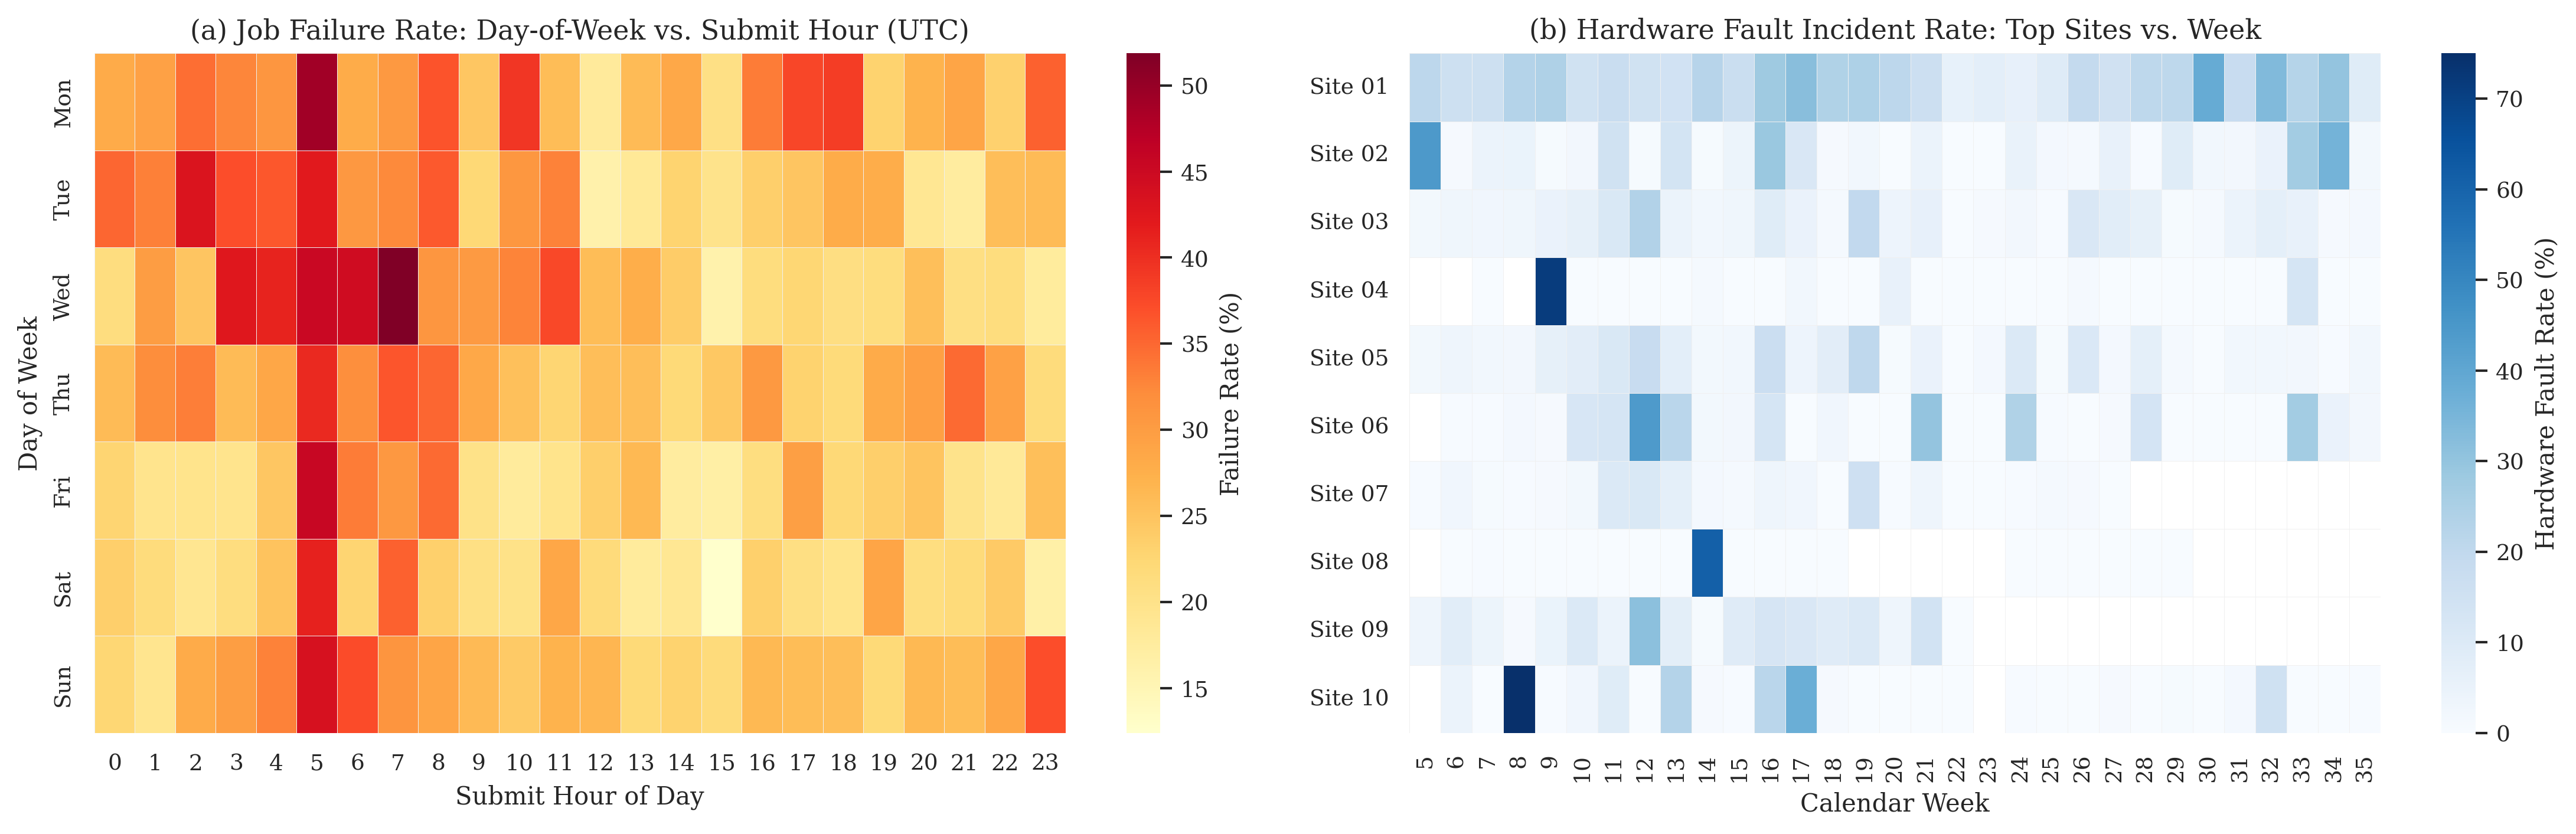

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

sns.set_theme(style="white", context="paper", font="serif")
plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

PAL = {"fail": "#D55E00", "hw": "#0072B2", "jobs": "#009E73"}

def sc(f):
    try:
        return f.collect(engine="streaming")
    except TypeError:
        return f.collect(streaming=True)


_sch = lf.collect_schema()


def _sec(c):
    if isinstance(_sch[c], pl.Datetime):
        return pl.col(c).dt.epoch("s").cast(pl.Float64)
    v = pl.col(c).cast(pl.Float64, strict=False)
    return (
        pl.when(v > 1e17)
        .then(v / 1e9)
        .when(v > 1e14)
        .then(v / 1e6)
        .when(v > 1e11)
        .then(v / 1e3)
        .otherwise(v)
    )


# Extract temporal components
dtq = pl.from_epoch(_sec(qcol).cast(pl.Int64), time_unit="s")
lfz = lf.with_columns(
    [
        dtq.dt.hour().alias("hour"),
        dtq.dt.weekday().alias("dow"),
        dtq.dt.week().alias("week"),
    ]
)

hd_df = sc(
    lfz.group_by(["dow", "hour"]).agg(
        (pl.col("Failed").mean() * 100.0).alias("fail_rate")
    )
).to_pandas()

hd_pivot = hd_df.pivot(
    index="dow", columns="hour", values="fail_rate"
).sort_index()

# Map integer DOW (1-7) to abbreviated day names
dow_map = {
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
    7: "Sun",
}
hd_pivot.index = [dow_map.get(i, i) for i in hd_pivot.index]

# Extract top 10 sites by total job volume
tops_raw = sc(
    lf.filter(pl.col(SITECOL).is_not_null())
    .group_by(SITECOL)
    .len()
    .sort("len", descending=True)
    .head(10)
)[SITECOL].to_list()

# Create anonymization dictionary (Site 01, Site 02, ...)
site_anonymizer = {site: f"Site {i+1:02d}" for i, site in enumerate(tops_raw)}

sw_df = sc(
    lfz.filter(pl.col(SITECOL).is_in(tops_raw))
    .group_by([SITECOL, "week"])
    .agg(
        (
            pl.col("hw_fault").filter(pl.col("fault_type") >= 0).mean() * 100.0
        ).alias("hw_rate")
    )
).to_pandas()

sw_pivot = sw_df.pivot(index=SITECOL, columns="week", values="hw_rate")

# Rename index to anonymized site labels
sw_pivot.index = [site_anonymizer.get(s, s) for s in sw_pivot.index]
sw_pivot = sw_pivot.sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8), dpi=300)

# Heatmap A: Submission Temporal Patterns
sns.heatmap(
    hd_pivot,
    ax=ax[0],
    cmap="YlOrRd",
    linewidths=0.2,
    linecolor="#f0f0f0",
    cbar_kws={"label": "Failure Rate (%)"},
)
ax[0].set_title("(a) Job Failure Rate: Day-of-Week vs. Submit Hour (UTC)")
ax[0].set_xlabel("Submit Hour of Day")
ax[0].set_ylabel("Day of Week")

# Heatmap B: Site Hardware Fault Rate Over Time
sns.heatmap(
    sw_pivot,
    ax=ax[1],
    cmap="Blues",
    linewidths=0.2,
    linecolor="#f0f0f0",
    cbar_kws={"label": "Hardware Fault Rate (%)"},
)
ax[1].set_title(
    "(b) Hardware Fault Incident Rate: Top Sites vs. Week"
)
ax[1].set_xlabel("Calendar Week")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
    }
)

COLORS = {
    "primary": "#1f77b4",
    "danger": "#d62728",
    "neutral": "#676767",
    "bar_fill": "#4c72b0",
    "volume_fill": "#bab9b9",
    "default_line": "#2b5c8f",
}

# README Exit Code Description Mapping
EC_DESCRIPTIONS = {
    1: "1 (Generic Error)",
    2: "2 (StdException / Shell Error)",
    3: "3 (Unknown Error)",
    4: "4 (BadAlloc)",
    6: "6 (ProductNotFound)",
    9: "9 (Configuration Error)",
    10: "10 (LogicError)",
    16: "16 (DataCorruption)",
    20: "20 (FileOpenError / Network)",
    21: "21 (FileReadError)",
    65: "65 (cet::exception / Missing Input)",
    66: "66 (std::exception)",
    68: "68 (std::bad_alloc)",
    90: "90 (FHiCL Parse Error)",
    91: "91 (FHiCL Parameter Error)",
    124: "124 (Job Timeout)",
    126: "126 (Command Cannot Execute)",
    127: "127 (Command Not Found)",
    129: "129 (SIGHUP / Lost Session)",
    130: "130 (SIGINT / Interrupted)",
    131: "131 (SIGQUIT)",
    134: "134 (SIGABRT / Self-Abort)",
    137: "137 (SIGKILL / OOM Timeout)",
    139: "139 (SIGSEGV / Segfault)",
    143: "143 (SIGTERM / Node Drain)",
    255: "255 (Generic Fatal Error)",
}

### Queue wait time analysis

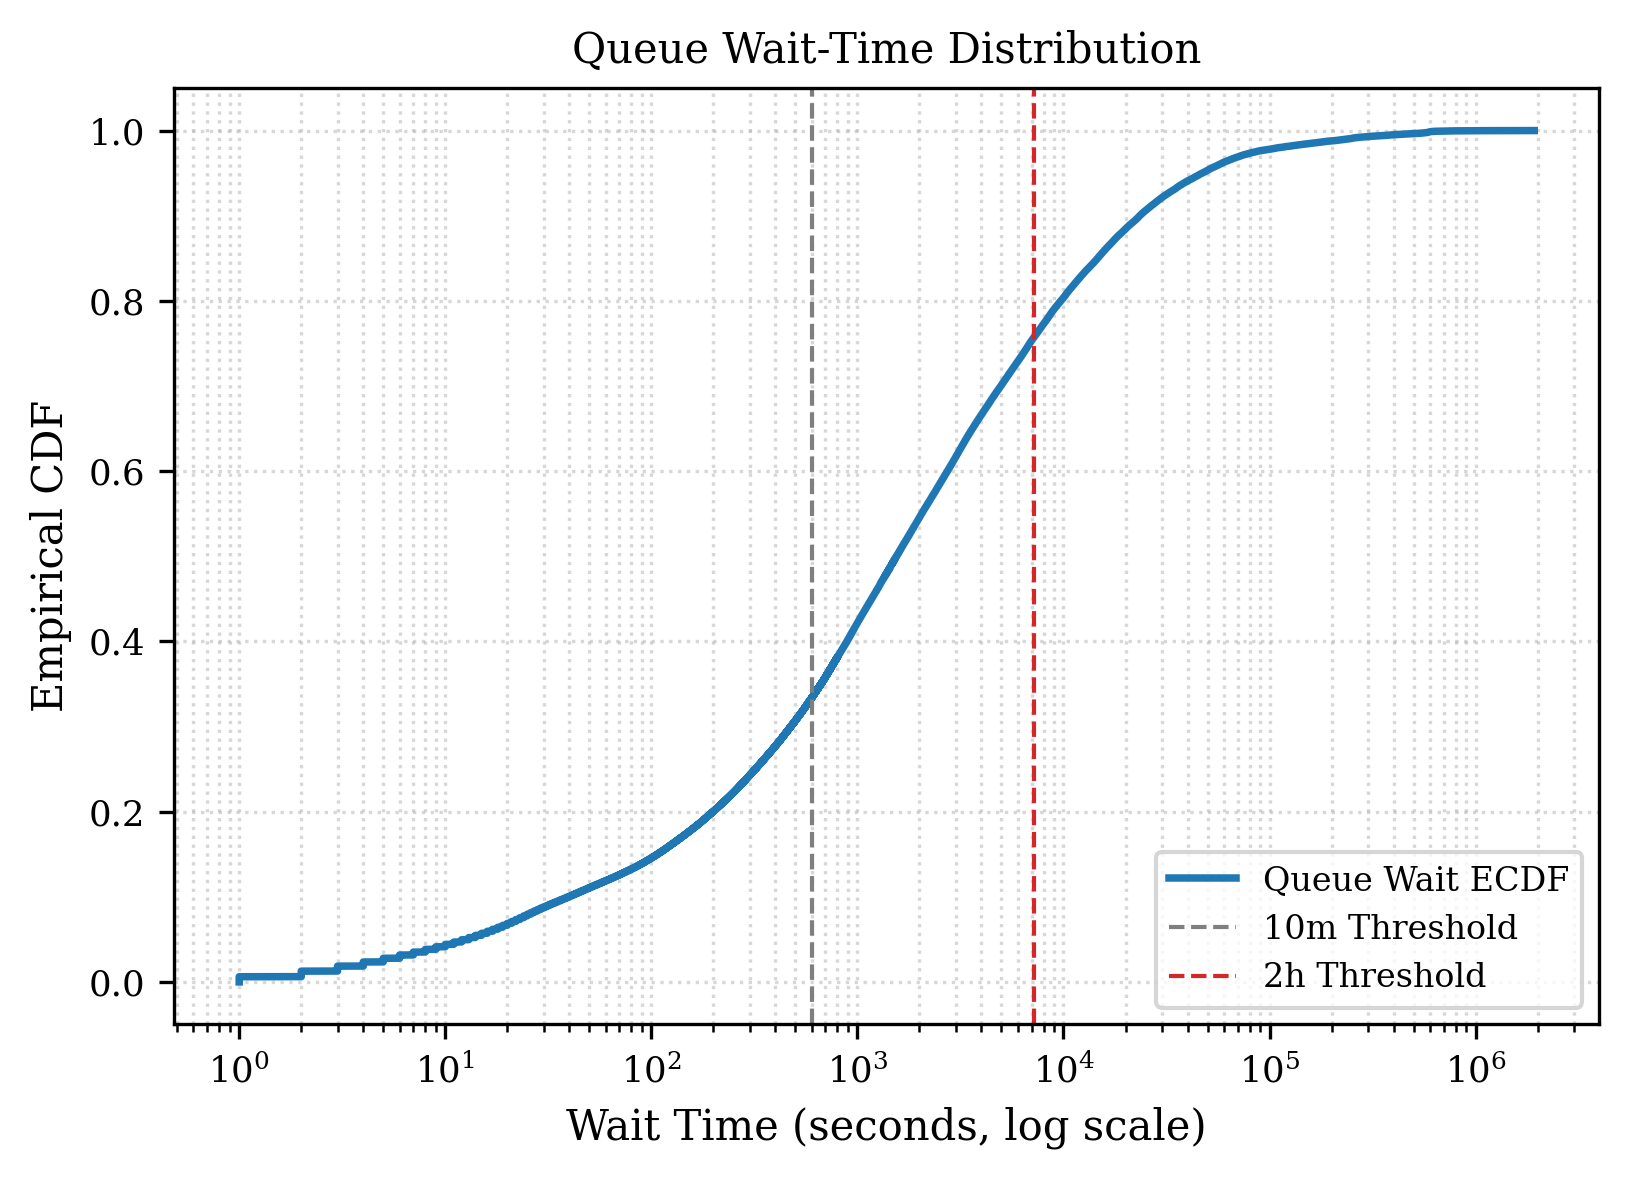

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4), dpi=300)

df_wait = (
    lf.select(pl.col("wait_s"))
    .drop_nulls()
    .filter(pl.col("wait_s") > 0)
    .collect()
)
wait_s = df_wait["wait_s"].to_numpy()
sorted_wait = np.sort(wait_s)
cdf = np.arange(1, len(sorted_wait) + 1) / len(sorted_wait)

ax.plot(sorted_wait, cdf, color=COLORS["primary"], linewidth=1.8, label="Queue Wait ECDF")
ax.set_xscale("log")

ax.axvline(600, color=COLORS["neutral"], linestyle="--", linewidth=1, label="10m Threshold")
ax.axvline(7200, color=COLORS["danger"], linestyle="--", linewidth=1, label="2h Threshold")

ax.set_xlabel("Wait Time (seconds, log scale)")
ax.set_ylabel("Empirical CDF")
ax.set_title("Queue Wait-Time Distribution")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("wait_time_distribution.pdf", bbox_inches="tight")
plt.show()

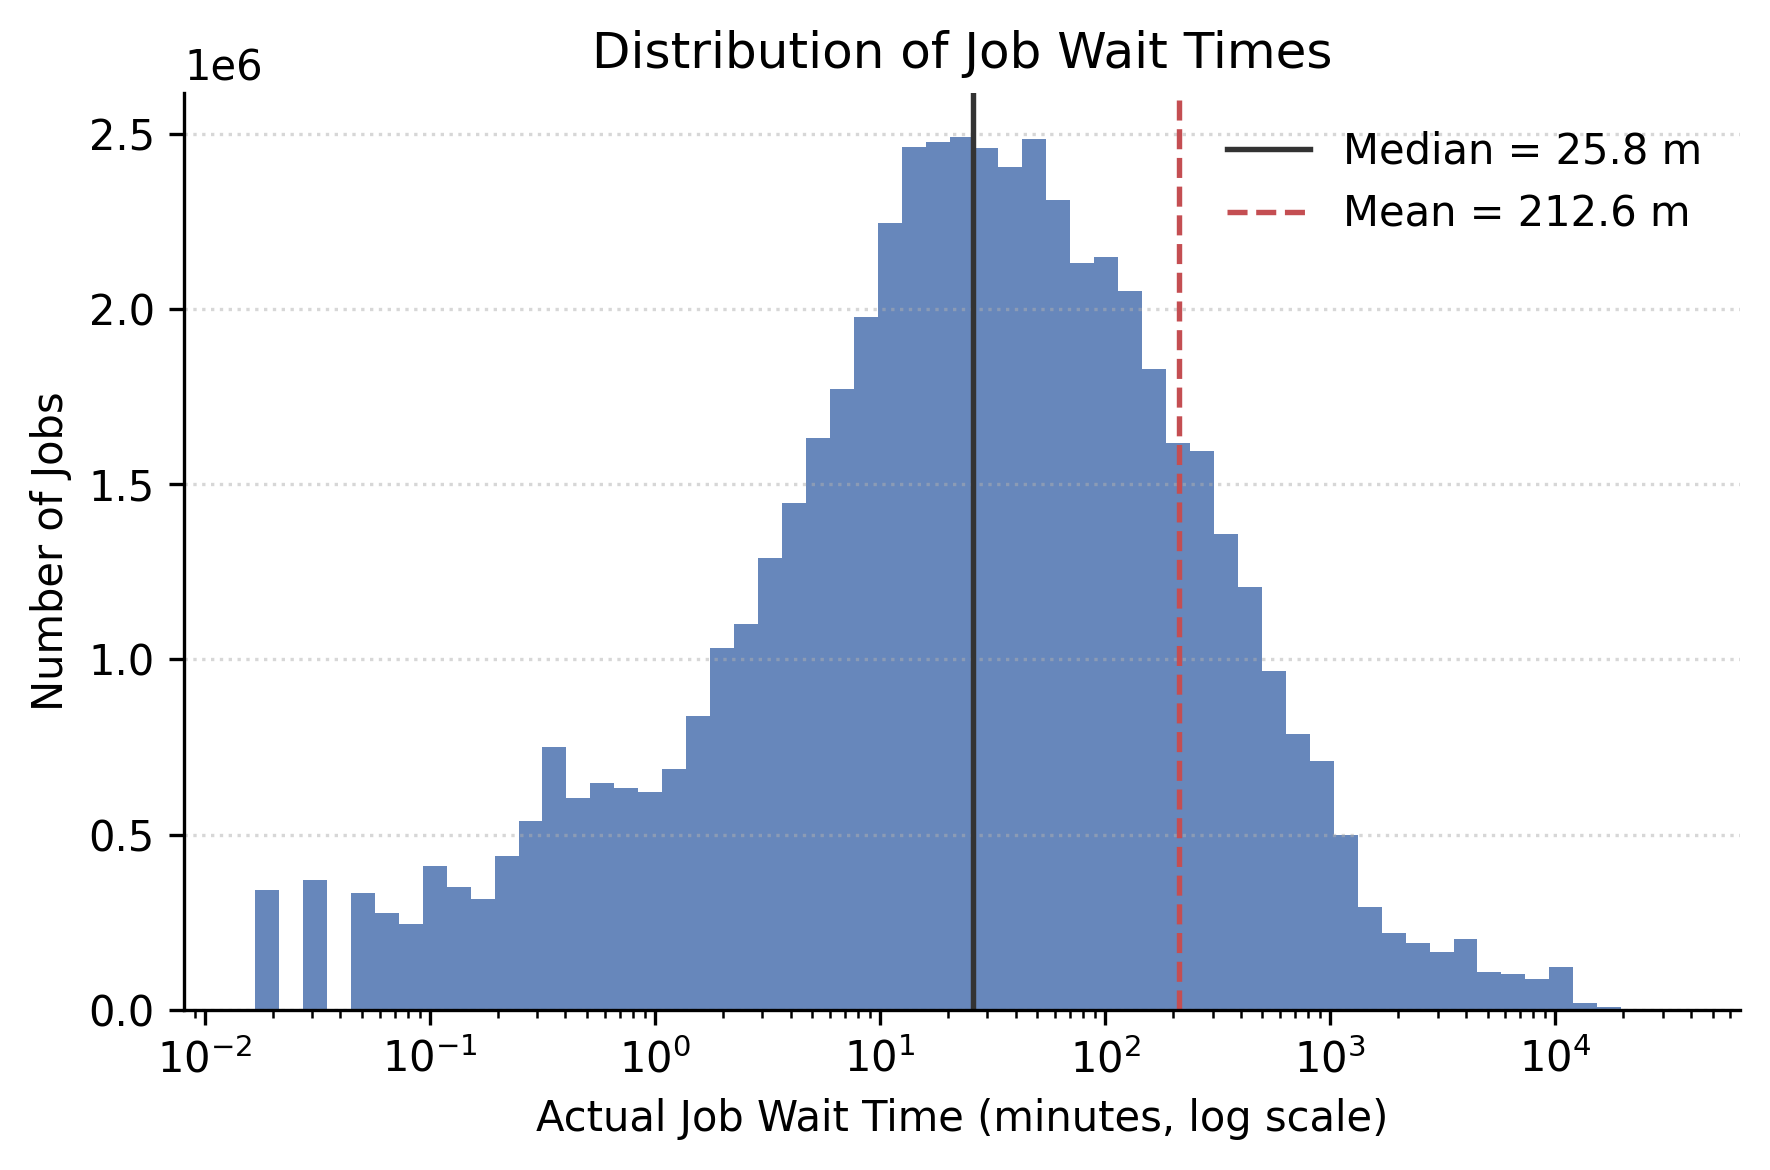

In [ ]:
BASE_COLOR = "#4C72B0"

df_wait = (
    lf.select(pl.col("wait_s"))
    .drop_nulls()
    .filter(pl.col("wait_s") > 0)
    .collect()
)
wait_s = df_wait["wait_s"].to_numpy()
wt_min = wait_s[wait_s > 0] / 60.0  # minutes; drop zero/negative edge cases for the log axis

mean_min = wt_min.mean()
median_min = np.median(wt_min)

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
bins = np.logspace(np.log10(max(wt_min.min(), 0.01)), np.log10(wt_min.max()), 60)
ax.hist(wt_min, bins=bins, color=BASE_COLOR, alpha=0.85)
ax.set_xscale("log")
ax.axvline(median_min, color="#333333", linewidth=1.3, label=f"Median = {median_min:,.1f} m")
ax.axvline(mean_min, color="#C44E52", linestyle="--", linewidth=1.3, label=f"Mean = {mean_min:,.1f} m")

ax.set_xlabel("Actual Job Wait Time (minutes, log scale)")
ax.set_ylabel("Number of Jobs")
ax.set_title("Distribution of Job Wait Times")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("output/wait_time_distribution_skew.pdf", bbox_inches="tight")
plt.savefig("output/wait_time_distribution_skew.png", bbox_inches="tight", dpi=300)
plt.show()


### Exit code analysis

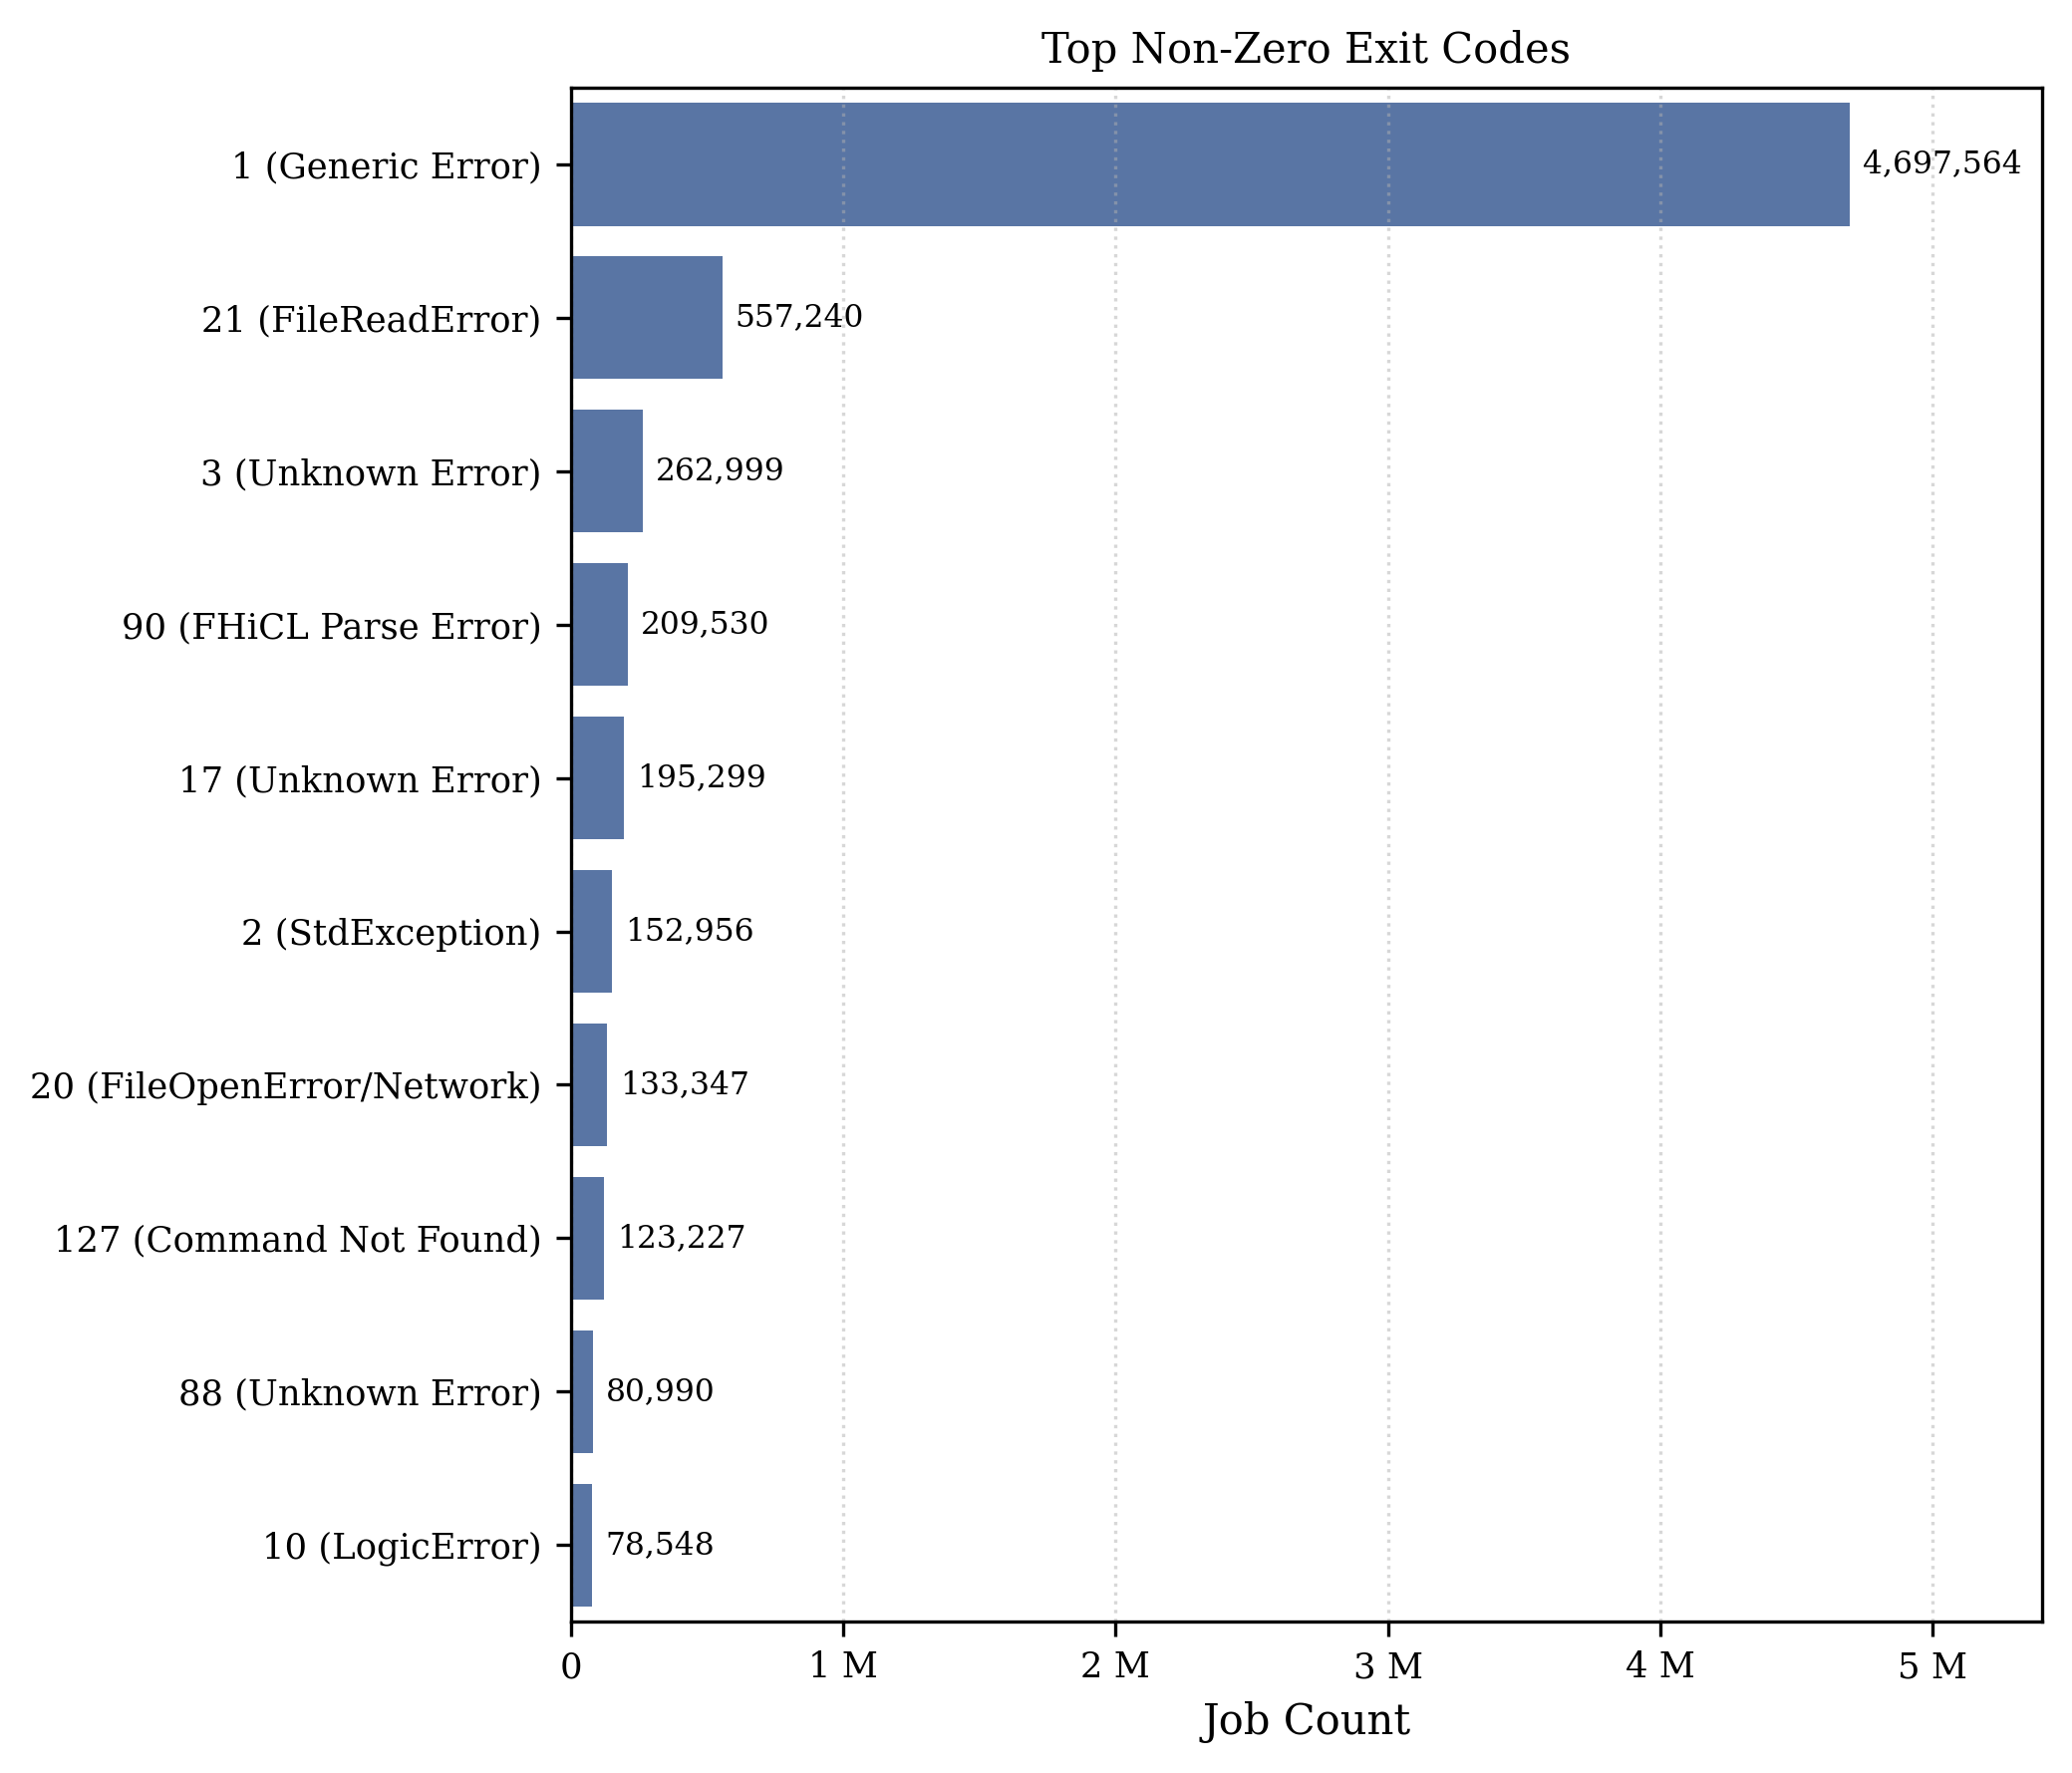

In [19]:
labels = {
    "1": "1 (Generic Error)",
    "2": "2 (StdException)",
    "3": "3 (Unknown Error)",
    "4": "4 (BadAlloc)",
    "5": "5 (BadExceptionType)",
    "6": "6 (ProductNotFound)",
    "9": "9 (Configuration Error)",
    "10": "10 (LogicError)",
    "11": "11 (UnimplementedFeature)",
    "12": "12 (InvalidReference)",
    "13": "13 (InvalidParameter)",
    "14": "14 (NullPointerError)",
    "15": "15 (EventTimeout)",
    "16": "16 (DataCorruption)",
    "17": "17 (Unknown Error)",
    "20": "20 (FileOpenError/Network)",
    "21": "21 (FileReadError)",
    "88": "88 (Unknown Error)",
    "90": "90 (FHiCL Parse Error)",
    "127": "127 (Command Not Found)"
}

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

df_ec = (
    lf.filter(
        (pl.col("ExitCode") != 0) & pl.col("ExitCode").is_not_null()
    )
    .group_by("ExitCode")
    .len()
    .sort("len", descending=True)
    .head(10)
    .collect()
    .to_pandas()
)

df_ec["Label"] = df_ec["ExitCode"].map(lambda x: labels.get(str(x), f"ExitCode {x}"))

sns.barplot(
    data=df_ec,
    y="Label",
    x="len",
    ax=ax,
    color=COLORS["bar_fill"],
    orient="h",
)

max_val = df_ec["len"].max()
for i, count in enumerate(df_ec["len"]):
    ax.text(
        count + (max_val * 0.01),
        i,
        f"{count:,}",
        va="center",
        fontsize=7.5,
    )

ax.set_xlim(0, max_val * 1.15)
ax.set_xlabel("Job Count")
ax.set_ylabel("")
ax.set_title("Top Non-Zero Exit Codes")
ax.grid(True, axis="x", linestyle=":", alpha=0.5)
ax.xaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
plt.savefig("output/exit_codes_distribution.pdf", bbox_inches="tight")
plt.show()

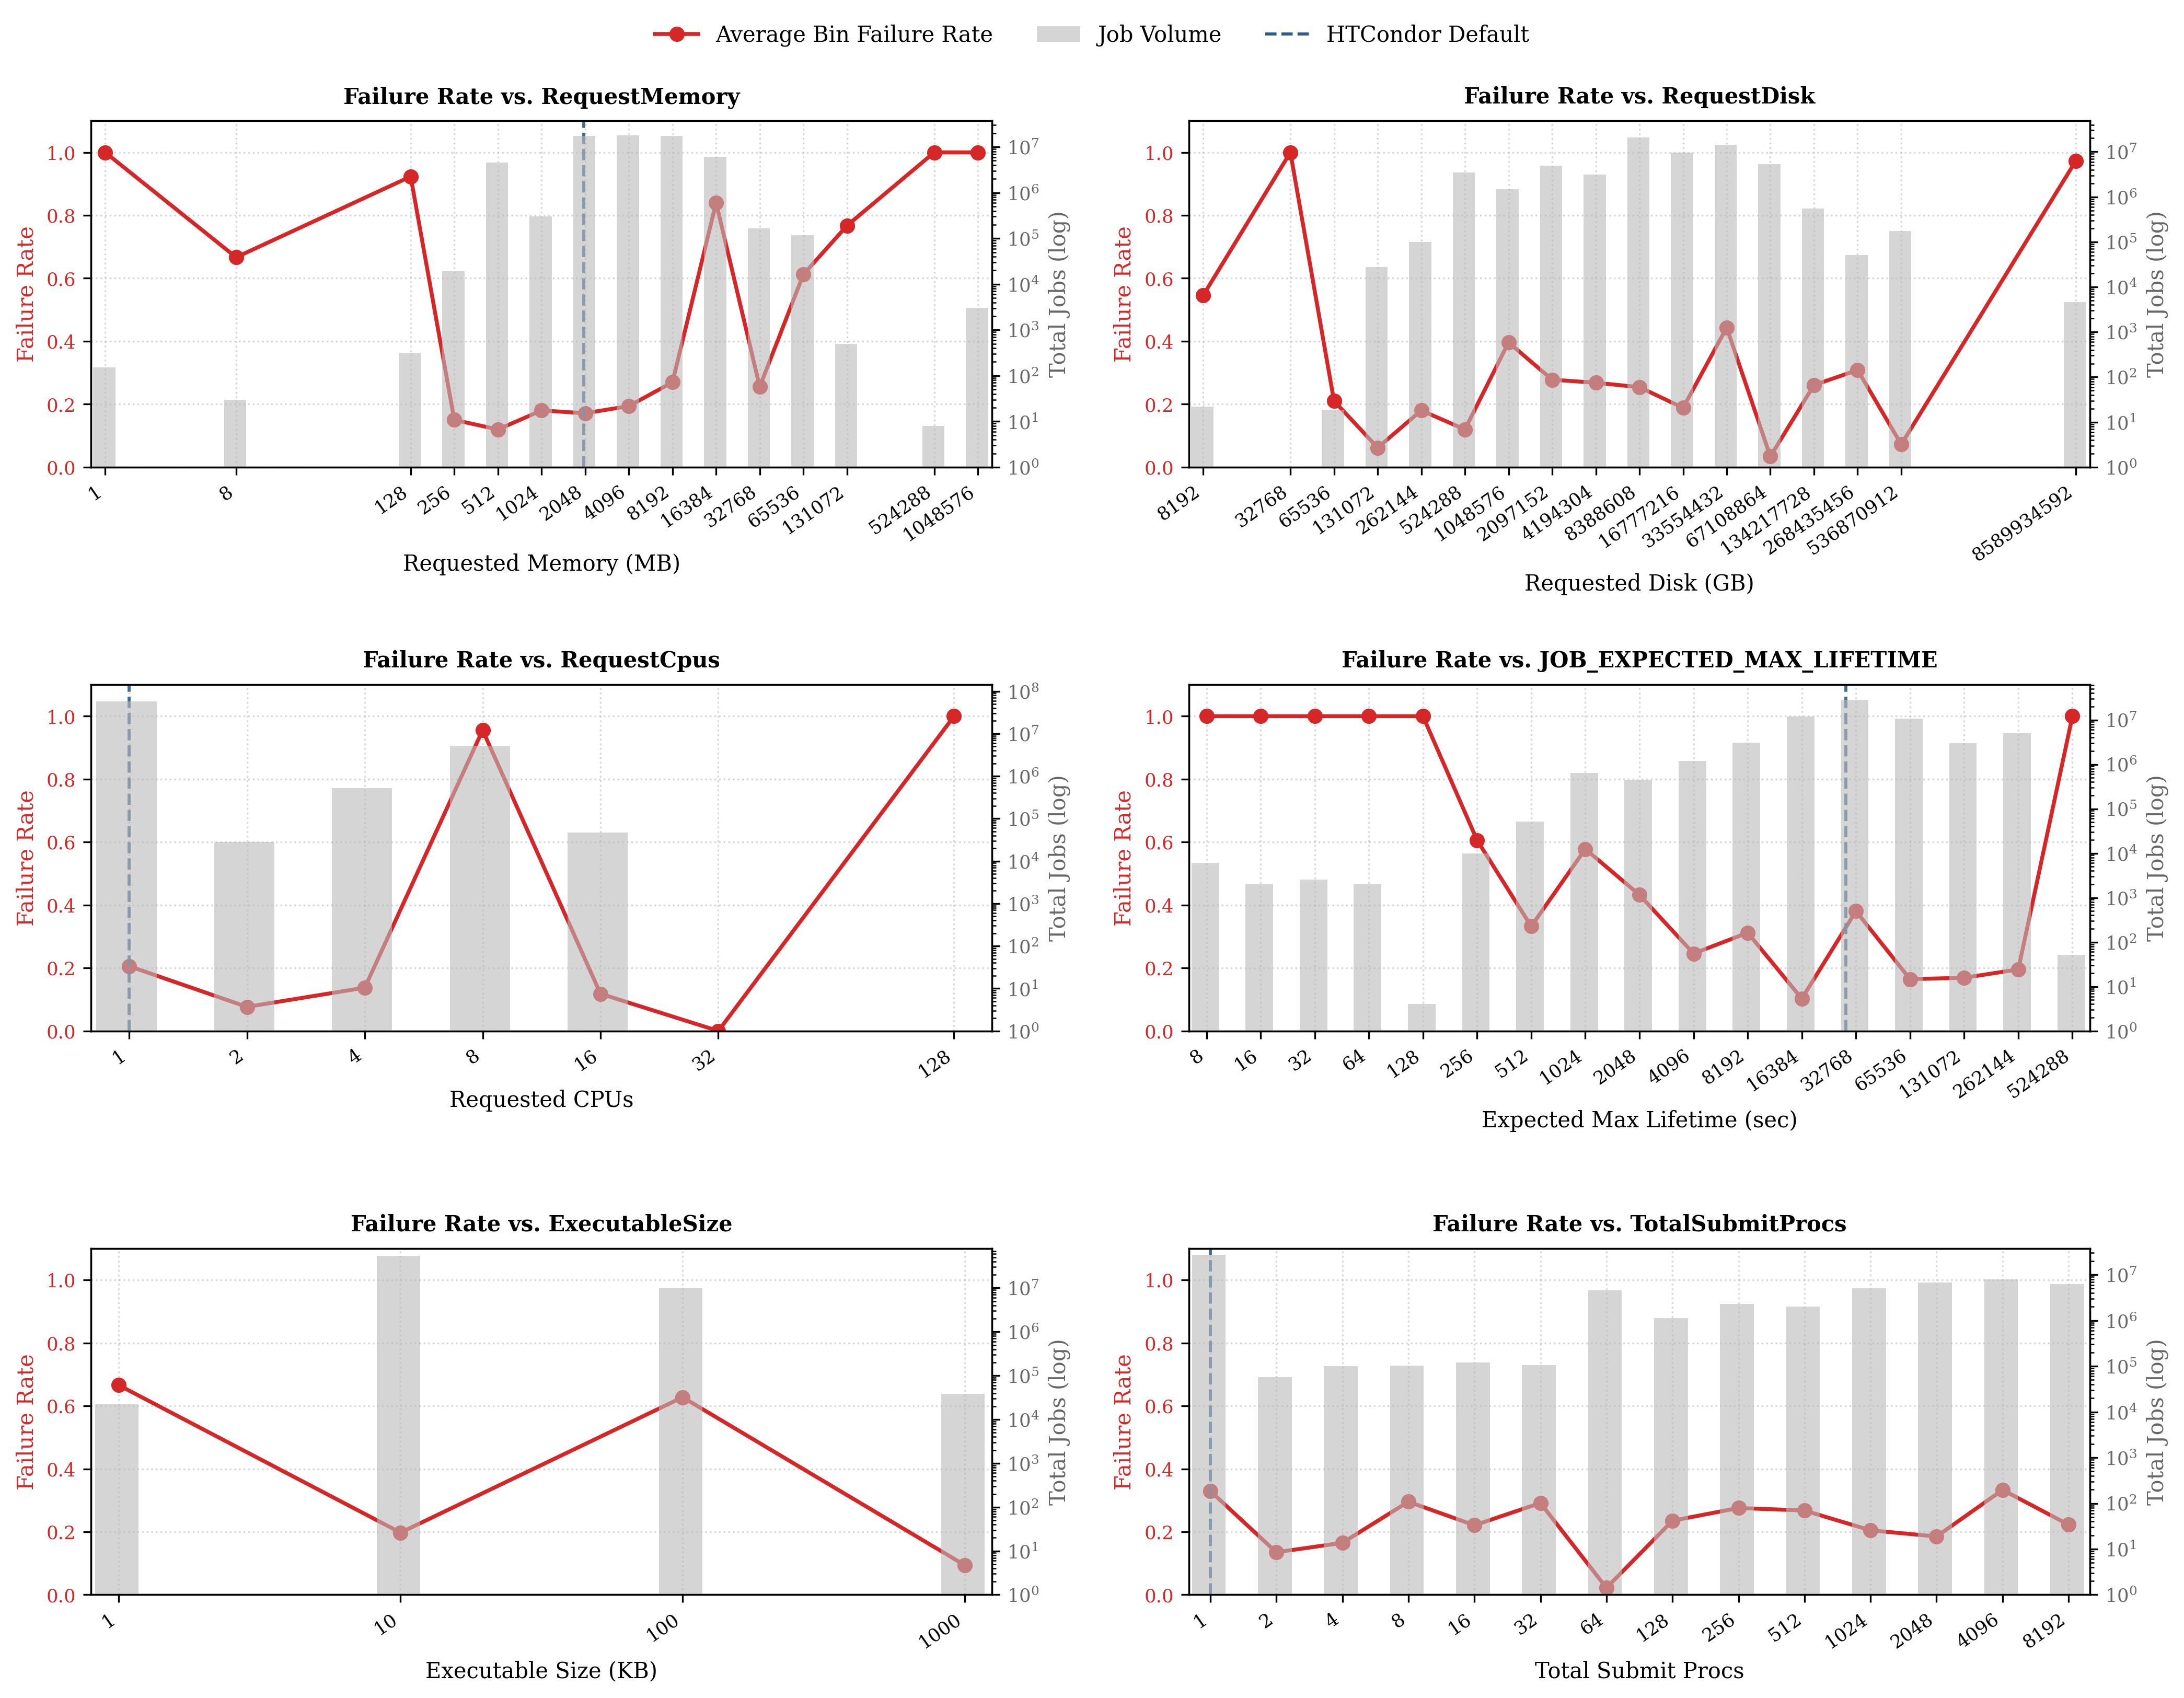

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

FEATURE_CONFIGS = [
    {
        "col": "RequestMemory",
        "mode": "log2",
        "default": 2000, 
        "label": "Requested Memory (MB)",
        "default_label": "Default (2000 MB)",
        "base": 2,
    },
    {
        "col": "RequestDisk",
        "mode": "log2",
        "label": "Requested Disk (GB)",
        "default": 10, 
        "default_label": "Default (10 GB)",
        "base": 2,
    },
    {
        "col": "RequestCpus",
        "mode": "log2",
        "label": "Requested CPUs",
        "default": 1.0,
        "default_label": "Default (1.0)",
        "base": 2,
    },
    {
        "col": "JOB_EXPECTED_MAX_LIFETIME",
        "mode": "log2",
        "default": 28800.0,
        "default_label": "Default (8 hours)",
        "label": "Expected Max Lifetime (sec)",
        "base": 2,
    },
    {
        "col": "ExecutableSize",
        "mode": "log10",
        "default": None,
        "default_label": "Default (None)",
        "label": "Executable Size (KB)",
        "base": 10,
    },
    {
        "col": "TotalSubmitProcs",
        "mode": "log2",
        "unit_scale": 1.0,
        "default": 1.0,
        "default_label": "Default (1.0)",
        "label": "Total Submit Procs",
        "base": 2,
    },
]

def format_tick_val(x, pos):
    """Formats tick labels: rounds floats cleanly and strips trailing zeros."""
    if abs(x - round(x)) < 1e-6:
        return f"{int(round(x))}"
    elif abs(x) < 1:
        return f"{x:.3f}".rstrip("0").rstrip(".")
    else:
        return f"{x:.2f}".rstrip("0").rstrip(".")

def extract_binned_feature_df(
    lf, col_name, mode, unit_scale=1.0, min_count=500
):
    """Aggregates job counts and failure rates per feature bin using Polars."""
    e = pl.col(col_name).cast(pl.Float64, strict=False)

    if mode == "log2":
        b_expr = e.log(2).round()
    elif mode == "log10":
        b_expr = e.log10().round()
    elif mode == "raw":
        b_expr = e.clip(0, 32).round()

    df = (
        lf.filter(e > 0)
        .with_columns(b_expr.alias("bin"))
        .group_by("bin")
        .agg(
            [
                pl.len().alias("count"),
                pl.col("Failed").mean().alias("fail_rate"),
            ]
        )
        # .filter(pl.col("count") >= min_count)
        .sort("bin")
        .collect()
        .to_pandas()
    )

    if mode == "log2":
        df["x_val"] = (2.0 ** df["bin"]) * unit_scale
    elif mode == "log10":
        df["x_val"] = (10.0 ** df["bin"]) * unit_scale
    elif mode == "raw":
        df["x_val"] = df["bin"] * unit_scale

    return df

fig, axes = plt.subplots(3, 2, figsize=(14, 11), dpi=300)
axes = axes.flatten()

for i, cfg in enumerate(FEATURE_CONFIGS):
    col = cfg["col"]
    ax = axes[i]

    if col not in lf.collect_schema().names():
        ax.set_visible(False)
        continue

    df_binned = extract_binned_feature_df(lf, col, cfg["mode"])
    if df_binned.empty:
        ax.set_visible(False)
        continue

    ax_twin = ax.twinx()

    x_vals = df_binned["x_val"].values
    bar_widths = x_vals * 0.35 if cfg["base"] is not None else 0.4

    # Secondary Y-Axis: Job Volume (Background Bars)
    ax_twin.bar(
        x_vals,
        df_binned["count"],
        width=bar_widths,
        color=COLORS["volume_fill"],
        alpha=0.6,
    )
    ax_twin.set_yscale("log")
    ax_twin.set_ylim(bottom=1)
    ax_twin.set_ylabel("Total Jobs (log)", color=COLORS["neutral"])
    ax_twin.tick_params(axis="y", labelcolor=COLORS["neutral"])
    ax_twin.grid(False)

    # Primary Y-Axis: Failure Rate Line
    ax.plot(
        x_vals,
        df_binned["fail_rate"],
        marker="o",
        color=COLORS["danger"],
        linewidth=1.8,
    )

    # Annotate DUNE/HTCondor Default Line
    if cfg.get("default") is not None:
        ax.axvline(
            x=cfg["default"],
            color=COLORS["default_line"],
            linestyle="--",
            linewidth=1.4,
            alpha=0.9,
            zorder=5,
        )

    # Axis Scaling & Formatting
    if cfg["base"] is not None:
        ax.set_xscale("log", base=cfg["base"])
        valid_ticks = np.sort(df_binned["x_val"].unique())
        ax.set_xticks(valid_ticks)
        ax.set_xlim(valid_ticks[0] * 0.8, valid_ticks[-1] * 1.25)
        ax.set_ylim(0, 1.1)
    else:
        ax.set_xscale("linear")
        valid_ticks = np.sort(df_binned["x_val"].unique())
        ax.set_xticks(valid_ticks[:: max(1, len(valid_ticks) // 8)])

    ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(format_tick_val))
    ax.xaxis.set_minor_locator(ticker.NullLocator())

    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

    ax.set_xlabel(cfg["label"])
    ax.set_ylabel("Failure Rate", color=COLORS["danger"])
    ax.tick_params(axis="y", labelcolor=COLORS["danger"])
    ax.set_title(f"Failure Rate vs. {col}", fontweight="bold", pad=8)
    ax.grid(True, which="both", linestyle=":", alpha=0.5)

# Shared Global Legend at top of figure
legend_elements = [
    Line2D(
        [0],
        [0],
        color=COLORS["danger"],
        marker="o",
        linewidth=1.8,
        label="Average Bin Failure Rate",
    ),
    Patch(facecolor=COLORS["volume_fill"], alpha=0.6, label="Job Volume"),
    Line2D(
        [0],
        [0],
        color=COLORS["default_line"],
        linestyle="--",
        linewidth=1.4,
        label="HTCondor Default",
    ),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.985),
    ncol=3,
    frameon=False,
    fontsize=10,
)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.8, w_pad=2.2)
plt.savefig("output/failure_vs_features_corr.pdf", bbox_inches="tight")
plt.show()

### Feature engineering

In [5]:
import torch 

# --- Configuration & Split Windows ---
TRAIN_YM = [202502, 202503, 202504, 202505, 202506]  # Feb - Jun
TEST_YM  = [202507, 202508]                          # Jul - Aug
MIN_QDATE = "2025-02-01"                             # Drop pre-window stragglers

_GPU = torch.cuda.is_available()
DEVICE = torch.device("cuda" if _GPU else "cpu")
XGB_DEV = "cuda" if _GPU else "cpu"
CB_TASK = "GPU" if _GPU else "CPU"
LGBM_DEV = "cpu"

# Feature Schema
SUB_CAT = ["Group", "Owner", "PomsLauncher", "CampaignName", "CampaignStageName", 
           "CampaignId", "CampaignStageId", "CampaignType", "TestLaunch", "JobsubGroup", 
           "Image", "BlacklistSites"]
SUB_NUM = ["RequestCpus", "RequestDisk", "RequestMemory", "RequestSlots", 
           "ExecutableSize", "TransferInputMB", "ExpectedLifetime", "TotalSubmitProcs"]
MATCH_CAT = ["MatchSite", "MatchEntry", "MatchQueue", "MatchResource", "MatchCpus"]
MATCH_NUM = ["CpusProvisioned", "DiskProvisioned", "MemoryProvisioned"]
CAT_ALL = SUB_CAT + MATCH_CAT
NUM_ALL = SUB_NUM + MATCH_NUM

# Standard column mapping
CAND = {
    "Group": ["Group", "AccountingGroup"], "Owner": ["Owner"],
    "PomsLauncher": ["POMS_LAUNCHER", "POMS4_LAUNCHER"], "CampaignName": ["POMS4_CAMPAIGN_NAME"],
    "CampaignStageName": ["POMS4_CAMPAIGN_STAGE_NAME"], "CampaignId": ["POMS4_CAMPAIGN_ID"],
    "CampaignStageId": ["POMS4_CAMPAIGN_STAGE_ID"],
    "CampaignType": ["DerivedCampaignType"],
    "TestLaunch": ["POMS4_TEST_LAUNCH"], "JobsubGroup": ["Jobsub_Group"],
    "Image": ["SingularityImage"], "BlacklistSites": ["Blacklist_Sites"],
    "MatchSite": ["MATCH_EXP_JOB_GLIDEIN_Site", "MATCH_GLIDEIN_Site"],
    "MatchEntry": ["MATCH_GLIDEIN_Entry_Name"], "MatchQueue": ["MATCH_GLIDEIN_SiteWMS_Queue"],
    "MatchResource": ["MachineAttrGLIDEIN_ResourceName0"], "MatchCpus": ["MachineAttrCpus0"],
    "Node": ["LastRemoteHost", "RemoteHost"],
    "RequestCpus": ["RequestCpus"], "RequestDisk": ["RequestDisk"], "RequestMemory": ["RequestMemory"],
    "RequestSlots": ["RequestSlots"], "ExecutableSize": ["ExecutableSize"],
    "TransferInputMB": ["TransferInputSizeMB"], "ExpectedLifetime": ["JOB_EXPECTED_MAX_LIFETIME"],
    "TotalSubmitProcs": ["TotalSubmitProcs"], "CpusProvisioned": ["CpusProvisioned"],
    "DiskProvisioned": ["DiskProvisioned"], "MemoryProvisioned": ["MemoryProvisioned"],
    "QDate": ["QDate_ms", "QDate"],
    "JobStart": ["JobStartDate_ms", "JobStartDate", "JobCurrentStartDate_ms", "JobCurrentStartDate"],
    "CompletionDate": ["CompletionDate_ms", "CompletionDate"],
}

### Deriving CampaignType from stage name

`POMS4_CAMPAIGN_TYPE` is null for every row in the raw data (100% -- verified
against all 32 partition files), including the ~25% of jobs that have real
`POMS4_CAMPAIGN_ID`/`NAME`/`STAGE_NAME` values. It was never populated
upstream; this isn't something earlier cells in this notebook broke.

Per the "Campaign Type" table in `FIFE-Docs.md`, the type can be recovered
from keywords in `POMS4_CAMPAIGN_STAGE_NAME` instead. Jobs with no POMS4_*
fields at all aren't part of any campaign -- these get `"User"`.

In [8]:
# Campaign-type keyword table, mirroring the "Campaign Type" table in
# FIFE-Docs.md. Edit here (and keep the doc in sync) to reclassify a
# stage-name substring.
CAMPAIGN_TYPE_KEYWORDS = {
    "Generation": ["gen", "dio", "endpoint", "corsika", "sim", "wiremod", "ly", "offset",
                   "spill", "g4", "beamgun", "decay", "surface", "cryo"],
    "Reconstruction": ["stage0", "stage1", "reco", "reco1", "reco2", "digi", "track", "decode",
                       "recluster", "fullproduction", "ndlar", "compress", "convert", "fmatch"],
    "Merging": ["merge", "skim", "hadd", "filter", "scrub", "watchdog", "sleep", "test",
                "fclless", "concat", "mix"],
    "Analysis": ["ana", "caf", "ntuple", "larcv"],
}


def _classify_campaign_type(stage_name):
    """Composite stage names (e.g. 'gen_g4_detsim_reco1_reco2_caf') match
    keywords from several categories at once. We take the LAST (rightmost)
    match, on the assumption that the terminal step is what the stage
    actually delivers -- that example ends in 'caf' -> Analysis, even though
    it runs gen/reco steps first. This tie-break decides ~2.98M jobs across
    45 composite stage names, so it's worth a sanity check against how
    these have been labeled by hand in the past.
    """
    low = stage_name.lower()
    best_cat, best_pos = None, -1
    for cat, kws in CAMPAIGN_TYPE_KEYWORDS.items():
        for kw in kws:
            pos = low.find(kw)
            if pos > best_pos:
                best_pos, best_cat = pos, cat
    return best_cat or "Unmapped"


# Build the lookup once over the distinct stage names (~164), then map the
# whole column against it -- far cheaper than a per-row Python call.
_distinct_stages = (
    lf.select(pl.col("POMS4_CAMPAIGN_STAGE_NAME").unique())
    .collect()["POMS4_CAMPAIGN_STAGE_NAME"].drop_nulls().to_list()
)
_stage_to_type = {s: _classify_campaign_type(s) for s in _distinct_stages}

# No POMS4 fields at all -> not part of a campaign -> a user job.
lf = lf.with_columns(
    pl.when(pl.col("POMS4_CAMPAIGN_STAGE_NAME").is_null())
      .then(pl.lit("User"))
      .otherwise(
          pl.col("POMS4_CAMPAIGN_STAGE_NAME").replace_strict(_stage_to_type, default="Unmapped")
      )
      .alias("DerivedCampaignType")
)

# Register the derived column in `have`, the same way cell 2 does for
# "Group". `have` is what CAND/cat_expr() gate on -- a column present in
# `lf` but missing from `have` is silently replaced by a constant 0, which
# is exactly the all-null CampaignType failure this cell exists to fix.
if "DerivedCampaignType" not in have:
    have.append("DerivedCampaignType")

_diag = lf.group_by("DerivedCampaignType").len().sort("len", descending=True).collect()
_total = _diag["len"].sum()
print("CampaignType distribution:")
for row in _diag.iter_rows(named=True):
    print(f"  {row['DerivedCampaignType']:15s} {row['len']:>12,}  ({100 * row['len'] / _total:5.2f}%)")

# Recover the integer code each label ends up with. cat_expr() hashes the
# string, then cell 17 dense-ranks via np.unique -- which sorts -- so a
# label's final code is the rank of its hash among the hashes of the labels
# actually present. Built from _diag (observed values) rather than a fixed
# list, so it stays correct if a filter ever drops a type entirely.
_present = _diag["DerivedCampaignType"].to_list()
_hashes = (
    pl.DataFrame({"v": _present})
    .select(
        (pl.col("v").cast(pl.Utf8).fill_null("__NA__").hash(seed=0) % 2147483629)
        .cast(pl.Int32).alias("h")
    )["h"].to_list()
)
CAMPAIGN_TYPE_CODES = {
    rank: lab
    for rank, (lab, _) in enumerate(sorted(zip(_present, _hashes), key=lambda kv: kv[1]))
}
print("\nCampaignType code -> label (saved to schema_meta.json):")
for _code, _lab in CAMPAIGN_TYPE_CODES.items():
    print(f"  {_code} -> {_lab}")

_unmapped = sorted(s for s, t in _stage_to_type.items() if t == "Unmapped")
assert not _unmapped, (
    f"{len(_unmapped)} stage name(s) matched no keyword: {_unmapped}. "
    f"Extend CAMPAIGN_TYPE_KEYWORDS above (and FIFE-Docs.md) to cover them."
)
print(f"\nAll {len(_distinct_stages)} distinct stage names mapped; "
      f"{_diag.height} unique CampaignType values.")


CampaignType distribution:
  User              48,042,514  (75.04%)
  Reconstruction     9,225,360  (14.41%)
  Analysis           5,223,471  ( 8.16%)
  Generation         1,462,717  ( 2.28%)
  Merging               71,013  ( 0.11%)

CampaignType code -> label (saved to schema_meta.json):
  0 -> Reconstruction
  1 -> Analysis
  2 -> User
  3 -> Merging
  4 -> Generation

All 164 distinct stage names mapped; 5 unique CampaignType values.


In [9]:
import os
import gc
import sys
import time
import datetime as _dt
import numpy as np
import polars as pl
import torch

def cat_expr(std):
    raw = R.get(std)
    if raw is None or raw not in have:
        return pl.lit(0).cast(pl.Int32).alias("c_" + std)
    return ((pl.col(raw).cast(pl.Utf8).fill_null("__NA__").hash(seed=0) % 2147483629)
            .cast(pl.Int32).alias("c_" + std))

def num_expr(std):
    raw = R.get(std)
    if raw is None or raw not in have:
        return pl.lit(0.0).cast(pl.Float32).alias("n_" + std)
    return pl.col(raw).cast(pl.Float32, strict=False).fill_null(0.0).alias("n_" + std)

R = {std: next((c for c in cands if c in have), None) for std, cands in CAND.items()}

sel_exprs = (
    [cat_expr(c) for c in CAT_ALL] + [cat_expr("Node")]
    + [num_expr(c) for c in NUM_ALL]
    + [to_sec(R["QDate"]).alias("t_q") if R["QDate"] else pl.lit(None).alias("t_q"),
       to_sec(R["JobStart"]).alias("t_s") if R["JobStart"] else pl.lit(None).alias("t_s"),
       to_sec(R["CompletionDate"]).alias("t_c") if R["CompletionDate"] else pl.lit(None).alias("t_c")]
    + [pl.col("Failed").cast(pl.Int8), pl.col("fault_type").cast(pl.Int8), pl.col("wait_s").cast(pl.Float64)]
)

t0 = time.time()
QMIN_S = _dt.datetime.fromisoformat(MIN_QDATE).replace(tzinfo=_dt.timezone.utc).timestamp()
df = lf.filter(to_sec(R["QDate"]) >= QMIN_S).select(sel_exprs).collect()
ntot = df.height
print(f"Loaded {ntot:,} rows into RAM in {time.time() - t0:.1f}s")

# Extract categorical codes
codes = np.column_stack([df["c_" + c].to_numpy() for c in CAT_ALL])
node_k = df["c_Node"].to_numpy()
cards = []
for j in range(codes.shape[1]):
    u, inv = np.unique(codes[:, j], return_inverse=True)
    codes[:, j] = inv.astype(np.int32)
    cards.append(len(u))

# Extract numerical features
X_num = np.column_stack([df["n_" + c].to_numpy() for c in NUM_ALL]).astype(np.float32)
for j in range(X_num.shape[1]):
    s = float(X_num[:, j].std()) or 1.0
    X_num[:, j] = (X_num[:, j] - X_num[:, j].mean()) / s

# Timestamps & Labels
qs = df["t_q"].to_numpy()
jst = df["t_s"].to_numpy()
js = jst  # Alias for start time
comp = df["t_c"].to_numpy()
wait_sv = df["wait_s"].to_numpy()

failed = df["Failed"].to_numpy()
ftype = df["fault_type"].to_numpy()
hw = (ftype == 1).astype(np.int8)

# Month split masking
dtq = pl.from_epoch(pl.Series(np.nan_to_num(qs).astype(np.int64)), time_unit="s")
ym = (dtq.dt.year().cast(pl.Int32) * 100 + dtq.dt.month().cast(pl.Int32)).to_numpy()
tr_mask = np.isin(ym, TRAIN_YM)
te_mask = np.isin(ym, TEST_YM)

print(f"{ntot:,} total rows | Train ({TRAIN_YM}): {tr_mask.sum():,} | Test ({TEST_YM}): {te_mask.sum():,}")

Loaded 64,025,075 rows into RAM in 17.9s
64,025,075 total rows | Train ([202502, 202503, 202504, 202505, 202506]): 48,546,633 | Test ([202507, 202508]): 15,478,442


In [10]:
TRAIL_WINDOWS = [900, 3600]          # 15 min & 1 hour trailing windows
TRAIL_NAMES = ["site_fail", "entry_fail", "node_fail", "site_hw", "node_hw", "camp_fail"]

n_cat, n_num = len(CAT_ALL), len(NUM_ALL)
n_base = n_cat + n_num
n_sc, n_sn = len(SUB_CAT), len(SUB_NUM)

XMATCH_COLS = (CAT_ALL + [c + " (std)" for c in NUM_ALL]
               + ["sin_hour@match", "cos_hour@match", "sin_wday@match", "cos_wday@match"]
               + [f"trail{w // 60}m_{nm}" for w in TRAIL_WINDOWS for nm in TRAIL_NAMES]
               + ["log_site_running@match", "log_total_running@match"])

XSUB_COLS = (SUB_CAT + [c + " (std)" for c in SUB_NUM]
             + ["sin_hour@submit", "cos_hour@submit", "sin_wday@submit", "cos_wday@submit"]
             + ["log_idle_queue_depth", "log_camp_trail_wait", "log_total_running@submit"])

NXM, NXS = len(XMATCH_COLS), len(XSUB_COLS)

# Vectorized helper for trailing failure/hardware rates
def trailing_rate(key, tref, tcomp, outcome, is_comp, window_s):
    n = len(key); w = int(window_s)
    ci = np.where(is_comp)[0]
    ck = np.asarray(key)[ci].astype(np.int64)
    ct = np.rint(np.asarray(tcomp)[ci]).astype(np.int64)
    co = np.asarray(outcome)[ci].astype(np.float64)
    if len(ct) == 0:
        return np.full(n, np.nan, np.float32), np.zeros(n, np.float32)
    o = np.lexsort((ct, ck)); ck, ct, co = ck[o], ct[o], co[o]
    csum = np.concatenate([[0.0], np.cumsum(co)])
    t0 = int(ct.min()); span = int(ct.max()) - t0 + w + 3
    comp_key = ck * span + (ct - t0)
    tref = np.asarray(tref); tcomp = np.asarray(tcomp); outcome = np.asarray(outcome)
    tq = np.where(np.isnan(tref), t0 - w - 10, np.rint(tref)).astype(np.int64)
    kq = np.asarray(key).astype(np.int64)
    hi = np.searchsorted(comp_key, kq * span + np.clip(tq - t0, -1, span - 2), "right")
    lo = np.searchsorted(comp_key, kq * span + np.clip(tq - w - t0, -1, span - 2), "right")
    cnt = (hi - lo).astype(np.float64); ssum = csum[hi] - csum[lo]
    self_in = np.asarray(is_comp) & ~np.isnan(tref) & (tcomp <= tref) & (tcomp > tref - window_s)
    ssum[self_in] -= outcome[self_in]; cnt[self_in] -= 1
    with np.errstate(invalid="ignore", divide="ignore"):
        rate = np.where(cnt > 0, ssum / np.maximum(cnt, 1), np.nan)
    return rate.astype(np.float32), cnt.astype(np.float32)

# Cyclical clock features helper
def cyc_of(t):
    d = pl.from_epoch(pl.Series(np.asarray(t)).cast(pl.Int64, strict=False), time_unit="s")
    h = d.dt.hour().to_numpy().astype(np.float64)
    dw = d.dt.weekday().to_numpy().astype(np.float64)
    return np.nan_to_num(np.column_stack([np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24),
                                          np.sin(2 * np.pi * dw / 7), np.cos(2 * np.pi * dw / 7)])).astype(np.float32)

print("Calculating trailing state features...")
comp_ok = ~np.isnan(np.asarray(comp)); H1 = 3600.0
fl64, hw64 = np.asarray(failed).astype(np.float64), hw.astype(np.float64)
jsf = np.where(np.isnan(np.asarray(js)), -1e18, np.asarray(js))
tref_m = np.where(np.isnan(np.asarray(js)), np.asarray(qs), np.asarray(js))

site_k = codes[:, CAT_ALL.index("MatchSite")]
entry_k = codes[:, CAT_ALL.index("MatchEntry")]
camp_k = codes[:, CAT_ALL.index("CampaignId")]

trail_specs = [(site_k, jsf, fl64), (entry_k, jsf, fl64), (node_k, jsf, fl64),
               (site_k, jsf, hw64), (node_k, jsf, hw64), (camp_k, qs, fl64)]

tr_all = []
for w in TRAIL_WINDOWS:
    for kv, tv, ov in trail_specs:
        r, _ = trailing_rate(kv, tv, comp, ov, comp_ok, float(w))
        tr_all.append(np.nan_to_num(r))

print("Calculating concurrency features...")
fin2 = ~np.isnan(np.asarray(jst)) & ~np.isnan(np.asarray(comp))
s2 = np.sort(np.asarray(jst)[fin2]); c2 = np.sort(np.asarray(comp)[fin2])

def running_total(t):
    r = (np.searchsorted(s2, t, "right") - np.searchsorted(c2, t, "right")).astype(np.float64)
    self_run = fin2 & (np.asarray(jst) <= t) & (np.asarray(comp) > t)
    r[self_run] -= 1
    return np.clip(r, 0, None)

def running_by_key(key, t):
    ki = np.asarray(key).astype(np.int64)
    ks = ki[fin2]
    st = np.rint(np.asarray(jst)[fin2]).astype(np.int64)
    ct = np.rint(np.asarray(comp)[fin2]).astype(np.int64)
    t0 = int(min(st.min(), ct.min())); span = int(max(st.max(), ct.max())) - t0 + 3
    a_s = np.sort(ks * span + (st - t0)); a_c = np.sort(ks * span + (ct - t0))
    q = ki * span + np.clip(np.rint(t).astype(np.int64) - t0, -1, span - 2)
    r = (np.searchsorted(a_s, q, "right") - np.searchsorted(a_c, q, "right")).astype(np.float64)
    self_run = fin2 & (np.asarray(jst) <= t) & (np.asarray(comp) > t)
    r[self_run] -= 1
    return np.clip(r, 0, None)

run_site = running_by_key(site_k, tref_m)
run_tot_m = running_total(tref_m)
cycS = cyc_of(tref_m)

# Assemble Xmatch in RAM
print("Assembling Xmatch matrix in RAM...")
Xmatch = np.empty((int(ntot), NXM), dtype=np.float32)
Xmatch[:, :n_cat] = codes
Xmatch[:, n_cat:n_base] = X_num
Xmatch[:, n_base:n_base + 4] = cycS
for j in range(len(tr_all)):
    Xmatch[:, n_base + 4 + j] = tr_all[j]
Xmatch[:, NXM - 2] = np.log1p(run_site)
Xmatch[:, NXM - 1] = np.log1p(run_tot_m)
del cycS, tr_all, run_site, run_tot_m

# Queue depth & submission features
print("Calculating submission & queue features...")
fin = ~np.isnan(np.asarray(jst))
q_fin = np.sort(np.asarray(qs)[fin]); s_fin = np.sort(np.asarray(jst)[fin])
idle = np.clip(np.searchsorted(q_fin, np.asarray(qs), "right")
               - np.searchsorted(s_fin, np.asarray(qs), "right"), 0, None).astype(np.float64)
wok = comp_ok & ~np.isnan(np.asarray(wait_sv))
campw, _ = trailing_rate(camp_k, qs, comp, np.nan_to_num(np.asarray(wait_sv)), wok, H1)
run_tot_q = running_total(np.asarray(qs))
cycQ = cyc_of(qs)

# Assemble Xsub in RAM
print("Assembling Xsub matrix in RAM...")
Xsub = np.empty((int(ntot), NXS), dtype=np.float32)
Xsub[:, :n_sc] = codes[:, :n_sc]
Xsub[:, n_sc:n_sc + n_sn] = X_num[:, :n_sn]
Xsub[:, n_sc + n_sn:n_sc + n_sn + 4] = cycQ
Xsub[:, -3] = np.log1p(idle)
Xsub[:, -2] = np.log1p(np.nan_to_num(campw))
Xsub[:, -1] = np.log1p(run_tot_q)
del cycQ, idle, campw, run_tot_q, q_fin, s_fin, jsf, fl64, hw64
gc.collect()

# Zero-copy views
X = Xmatch[:, :n_base]
trail = Xmatch[:, n_base + 4:NXM - 2]
cyc_q = Xsub[:, n_sc + n_sn:n_sc + n_sn + 4]

print(f"Xmatch shape: {Xmatch.shape}  (base {n_base} + cyc 4 + trailing {6 * len(TRAIL_WINDOWS)} + concurrency 2)")
print(f"Xsub shape:   {Xsub.shape}  (sub cat {n_sc} + sub num {n_sn} + cyc 4 + queue state 3)")

Calculating trailing state features...
Calculating concurrency features...
Assembling Xmatch matrix in RAM...
Calculating submission & queue features...
Assembling Xsub matrix in RAM...
Xmatch shape: (64025075, 46)  (base 28 + cyc 4 + trailing 12 + concurrency 2)
Xsub shape:   (64025075, 27)  (sub cat 12 + sub num 8 + cyc 4 + queue state 3)


### Saving training data for later runs (skip)

In [11]:
import os 
import json
import numpy as np

SAVE_DIR = "/mnt/scratch/fast0/amaustin/datasets/fife/"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Saving training data to {SAVE_DIR}")

np.save(os.path.join(SAVE_DIR, "Xmatch.npy"), Xmatch)
np.save(os.path.join(SAVE_DIR, "Xsub.npy"), Xsub)

np.savez_compressed(
    os.path.join(SAVE_DIR, "targets_and_masks.npz"),
    failed=failed,
    hw=hw,
    wait_sv=wait_sv,
    tr_mask=tr_mask,
    te_mask=te_mask,
    qs=qs,
    jst=jst,
    comp=comp,
)

metadata = {
    "XMATCH_COLS": XMATCH_COLS,
    "XSUB_COLS": XSUB_COLS,
    "cards": [int(c) for c in cards],
    "NCAT_MATCH": len(CAT_ALL),
    "NCAT_SUB": len(SUB_CAT),
    "n_base": n_base,
}

# Code -> label for CampaignType (JSON object keys must be strings). The
# codes come from a hash + dense-rank, so they carry no inherent meaning --
# without this map the column is unreadable downstream.
if "CAMPAIGN_TYPE_CODES" in dir():
    metadata["CAMPAIGN_TYPE_CODES"] = {str(k): v for k, v in CAMPAIGN_TYPE_CODES.items()}
else:
    print("[!] CAMPAIGN_TYPE_CODES not defined -- run the CampaignType derivation cell.")

with open(os.path.join(SAVE_DIR, "schema_meta.json"), "w") as f:
    json.dump(metadata, f, indent=2)

Saving training data to /mnt/scratch/fast0/amaustin/datasets/fife/


### Reloading training data

In [2]:
%%time
import os
import json
import numpy as np

SAVE_DIR = "/mnt/scratch/fast0/amaustin/datasets/fife/"
targets = np.load(os.path.join(SAVE_DIR, "targets_and_masks.npz"))

# for key in targets.files:
#     np.save(os.path.join(SAVE_DIR, f"{key}.npy"), targets[key])

Xmatch = np.load(os.path.join(SAVE_DIR, "Xmatch.npy"), mmap_mode="r")
Xsub = np.load(os.path.join(SAVE_DIR, "Xsub.npy"), mmap_mode="r")

failed = np.load(os.path.join(SAVE_DIR, "failed.npy"), mmap_mode="r")
hw = np.load(os.path.join(SAVE_DIR, "hw.npy"), mmap_mode="r")
wait_sv = np.load(os.path.join(SAVE_DIR, "wait_sv.npy"), mmap_mode="r")
tr_mask = np.load(os.path.join(SAVE_DIR, "tr_mask.npy"), mmap_mode="r")
te_mask = np.load(os.path.join(SAVE_DIR, "te_mask.npy"), mmap_mode="r")

with open(os.path.join(SAVE_DIR, "schema_meta.json"), "r") as f:
    meta = json.load(f)

XMATCH_COLS = meta["XMATCH_COLS"]
XSUB_COLS = meta["XSUB_COLS"]
cards = meta["cards"]
NCAT_MATCH = meta["NCAT_MATCH"]
NCAT_SUB = meta["NCAT_SUB"]
n_base = meta["n_base"]

X = Xmatch[:, :n_base]

print(f"Loaded Xmatch {Xmatch.shape} and Xsub {Xsub.shape}")
print(f"Train split: {tr_mask.sum():,} rows | Test split: {te_mask.sum():,} rows")

Loaded Xmatch (64025075, 46) and Xsub (64025075, 27)
Train split: 48,546,633 rows | Test split: 15,478,442 rows
CPU times: user 1.93 s, sys: 7.36 ms, total: 1.94 s
Wall time: 68.5 ms


In [28]:
# FI -- feature inventory: exactly what each model trains on
print(f"Xmatch {Xmatch.shape} -- match-time tasks (Failed, hw_fault, 3-class fault):")
for i, nme in enumerate(XMATCH_COLS):
    print(f"  [{i:2d}] {nme}")
print(f"\nXsub {Xsub.shape} -- submission-time task (wait_time):")
for i, nme in enumerate(XSUB_COLS):
    print(f"  [{i:2d}] {nme}")
print("\nstate variables: trail1h_* (leak-free trailing rates, 1h window, self-excluded),")
print("  log_idle_queue_depth (submitted-not-started at submit), log_camp_trail_wait,")
print("  log_*_running (leak-free concurrent-running counts, self-excluded)")
print("targets: Failed (binary) | hw_fault (binary; matched & typed rows) | "
      "fault_type (3-class) | wait_log = log1p(wait s)")

Xmatch (64025075, 46) -- match-time tasks (Failed, hw_fault, 3-class fault):
  [ 0] Group
  [ 1] Owner
  [ 2] PomsLauncher
  [ 3] CampaignName
  [ 4] CampaignStageName
  [ 5] CampaignId
  [ 6] CampaignStageId
  [ 7] CampaignType
  [ 8] TestLaunch
  [ 9] JobsubGroup
  [10] Image
  [11] BlacklistSites
  [12] MatchSite
  [13] MatchEntry
  [14] MatchQueue
  [15] MatchResource
  [16] MatchCpus
  [17] RequestCpus (std)
  [18] RequestDisk (std)
  [19] RequestMemory (std)
  [20] RequestSlots (std)
  [21] ExecutableSize (std)
  [22] TransferInputMB (std)
  [23] ExpectedLifetime (std)
  [24] TotalSubmitProcs (std)
  [25] CpusProvisioned (std)
  [26] DiskProvisioned (std)
  [27] MemoryProvisioned (std)
  [28] sin_hour@match
  [29] cos_hour@match
  [30] sin_wday@match
  [31] cos_wday@match
  [32] trail15m_site_fail
  [33] trail15m_entry_fail
  [34] trail15m_node_fail
  [35] trail15m_site_hw
  [36] trail15m_node_hw
  [37] trail15m_camp_fail
  [38] trail60m_site_fail
  [39] trail60m_entry_fail
  [40

In [14]:
np.unique(Xmatch[:, XMATCH_COLS.index("CampaignType")])

array([0., 1., 2., 3., 4.], dtype=float32)

### Baseline experiments setup

In [4]:
# E1: split-protocol decomposition (Delta): random vs temporal on the same features
import psutil

def mem_gb():
    return psutil.Process().memory_info().rss / (1024 ** 3)

# Target vector & population indices
yv = failed
idx = np.arange(len(yv))

# 1. Temporal split indices (Feb-Jun Train vs Jul-Aug Test)
tri_t = np.where(tr_mask)[0]
tei_t = np.where(te_mask)[0]

# 2. Random split indices (same test size, randomly sampled across all data)
rng = np.random.default_rng(0)
perm = rng.permutation(idx)
rte = np.sort(perm[:len(tei_t)])
rtr = np.sort(perm[len(tei_t):])

E1_SPLITS = [("random", rtr, rte), ("temporal", tri_t, tei_t)]

# Storage dicts (accumulate results across individual model cells)
E1_IMP, E1_CM = {}, {}

print(f"E1 splits prepared: Random ({len(rtr):,} train / {len(rte):,} test) | Temporal ({len(tri_t):,} train / {len(tei_t):,} test)")

E1 splits prepared: Random (48,546,633 train / 15,478,442 test) | Temporal (48,546,633 train / 15,478,442 test)


In [17]:
import importlib
import train.tree
importlib.reload(train.tree)
import eval.harness
importlib.reload(eval.harness)
from eval.harness import run_e1_model

print("--- Running E1: XGBoost ---")
print("-" * 55)

run_e1_model("xgboost", Xmatch, yv, E1_SPLITS, E1_IMP, E1_CM, NCAT_MATCH)

print("-" * 55)
print(f"[mem] Peak RSS: {mem_gb():.2f} GB", flush=True)

--- Running E1: XGBoost ---
-------------------------------------------------------


/home/amaustin/miniconda3/lib/python3.13/site-packages/xgboost/core.py:751: UserWarning: [10:41:03] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[xgboost] Saved model to /mnt/scratch/fast0/amaustin/tree-models/xgboost_bin_random.json
model     split      ROC    PR     F1     Prec   Rec
xgboost   random     0.985  0.968  0.898  0.907  0.889
Total time: 35.25 seconds
[xgboost] Saved model to /mnt/scratch/fast0/amaustin/tree-models/xgboost_bin_temporal.json
model     split      ROC    PR     F1     Prec   Rec
xgboost   temporal   0.883  0.839  0.731  0.815  0.662
Total time: 34.37 seconds
xgboost   Delta      -0.101  -0.130  -0.167  -0.091  -0.228
-------------------------------------------------------
[mem] Peak RSS: 14.30 GB


In [5]:
import importlib
import train.tree
importlib.reload(train.tree)
import eval.harness
importlib.reload(eval.harness)
from eval.harness import run_e1_model

print("--- Running E1: CatBoost ---")
print("-" * 55)

run_e1_model("catboost", Xmatch, yv, E1_SPLITS, E1_IMP, E1_CM, NCAT_MATCH)

print("-" * 55)
print(f"[mem] Peak RSS: {mem_gb():.2f} GB", flush=True)

--- Running E1: CatBoost ---
-------------------------------------------------------
[catboost] Saved model to /mnt/scratch/fast0/amaustin/models/catboost_bin_random.txt
model     split      ROC    PR     F1     Prec   Rec
catboost  random     0.977  0.955  0.876  0.891  0.861
Total time: 52.63 seconds
[catboost] Saved model to /mnt/scratch/fast0/amaustin/models/catboost_bin_temporal.txt
model     split      ROC    PR     F1     Prec   Rec
catboost  temporal   0.912  0.872  0.769  0.842  0.707
Total time: 51.23 seconds
catboost  Delta      -0.065  -0.083  -0.107  -0.049  -0.154
-------------------------------------------------------
[mem] Peak RSS: 34.79 GB


In [13]:
import importlib
import train.saint
importlib.reload(train.saint)
import eval.harness
importlib.reload(eval.harness)
from eval.harness import run_e1_model

print('--- Running E1: SAINT ---')
print('-' * 55)

run_e1_model('saint', Xmatch, yv, E1_SPLITS, E1_IMP, E1_CM, NCAT_MATCH)

print('-' * 55)
print(f'[mem] Peak RSS: {mem_gb():.2f} GB', flush=True)

--- Running E1: SAINT ---
-------------------------------------------------------
    [SAINT] Training on cuda | amp=True | batch_size=16384
    [SAINT] Epoch 01/10 | Loss: 0.2989 | Val AUC: 0.98324 (Best: 0.98324)
    [SAINT] Epoch 02/10 | Loss: 0.2275 | Val AUC: 0.98650 (Best: 0.98650)
    [SAINT] Epoch 03/10 | Loss: 0.2098 | Val AUC: 0.98772 (Best: 0.98772)
    [SAINT] Epoch 04/10 | Loss: 0.2001 | Val AUC: 0.98884 (Best: 0.98884)
    [SAINT] Epoch 05/10 | Loss: 0.1938 | Val AUC: 0.98923 (Best: 0.98923)
    [SAINT] Epoch 06/10 | Loss: 0.1893 | Val AUC: 0.98969 (Best: 0.98969)
    [SAINT] Epoch 07/10 | Loss: 0.1861 | Val AUC: 0.98975 (Best: 0.98975)
    [SAINT] Epoch 08/10 | Loss: 0.1834 | Val AUC: 0.99015 (Best: 0.99015)
    [SAINT] Epoch 09/10 | Loss: 0.1812 | Val AUC: 0.99076 (Best: 0.99076)
    [SAINT] Epoch 10/10 | Loss: 0.1793 | Val AUC: 0.99090 (Best: 0.99090)
saint     random     0.991  0.980  0.923  0.932  0.914
    [SAINT] Training on cuda | amp=True | batch_size=16384
    [

In [3]:
import importlib
import train.ft
importlib.reload(train.ft)
import eval.harness
importlib.reload(eval.harness)
from eval.harness import run_e1_model

print('--- Running E1: TSMixer ---')
print('-' * 55)

run_e1_model('tsmixer', Xmatch, yv, E1_SPLITS, E1_IMP, E1_CM, NCAT_MATCH)

print('-' * 55)
print(f'[mem] Peak RSS: {mem_gb():.2f} GB', flush=True)

--- Running E1: TSMixer ---
-------------------------------------------------------
    [TSMixer] Training on cuda | amp=True | batch_size=16384 | split=random
    [TSMixer] Epoch 01/12 | Loss: 0.4652 | Val AUC: 0.95164 (Best: 0.95164)
    [TSMixer] Epoch 02/12 | Loss: 0.3834 | Val AUC: 0.96021 (Best: 0.96021)
    [TSMixer] Epoch 03/12 | Loss: 0.3522 | Val AUC: 0.96597 (Best: 0.96597)
    [TSMixer] Epoch 04/12 | Loss: 0.3335 | Val AUC: 0.96964 (Best: 0.96964)
    [TSMixer] Epoch 05/12 | Loss: 0.3211 | Val AUC: 0.97298 (Best: 0.97298)
    [TSMixer] Epoch 06/12 | Loss: 0.3121 | Val AUC: 0.97392 (Best: 0.97392)
    [TSMixer] Epoch 07/12 | Loss: 0.3056 | Val AUC: 0.97613 (Best: 0.97613)
    [TSMixer] Epoch 08/12 | Loss: 0.3008 | Val AUC: 0.97665 (Best: 0.97665)
    [TSMixer] Epoch 09/12 | Loss: 0.2967 | Val AUC: 0.97682 (Best: 0.97682)
    [TSMixer] Epoch 10/12 | Loss: 0.2933 | Val AUC: 0.97765 (Best: 0.97765)
    [TSMixer] Saved checkpoint to /mnt/scratch/fast0/amaustin/dl-tabular-models/

#### E1 Results

In [ ]:
%%time
import warnings
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import load_saved_importances

# Prepare evaluation slice
eval_idx = tei_t[:200000]
X_eval = np.ascontiguousarray(Xmatch[eval_idx], dtype=np.float32)
y_eval = np.ascontiguousarray(yv[eval_idx])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    E1_IMP = load_saved_importances(
        models=["xgboost", "lightgbm", "catboost", "ft", "tsmixer", "mlp", "tabnet", "saint"],
        splits=["random", "temporal"],
        n_feats=len(XMATCH_COLS),
        X_eval=X_eval,
        y_eval=y_eval
    )

#### Feature gain shift (random split -> temporal)

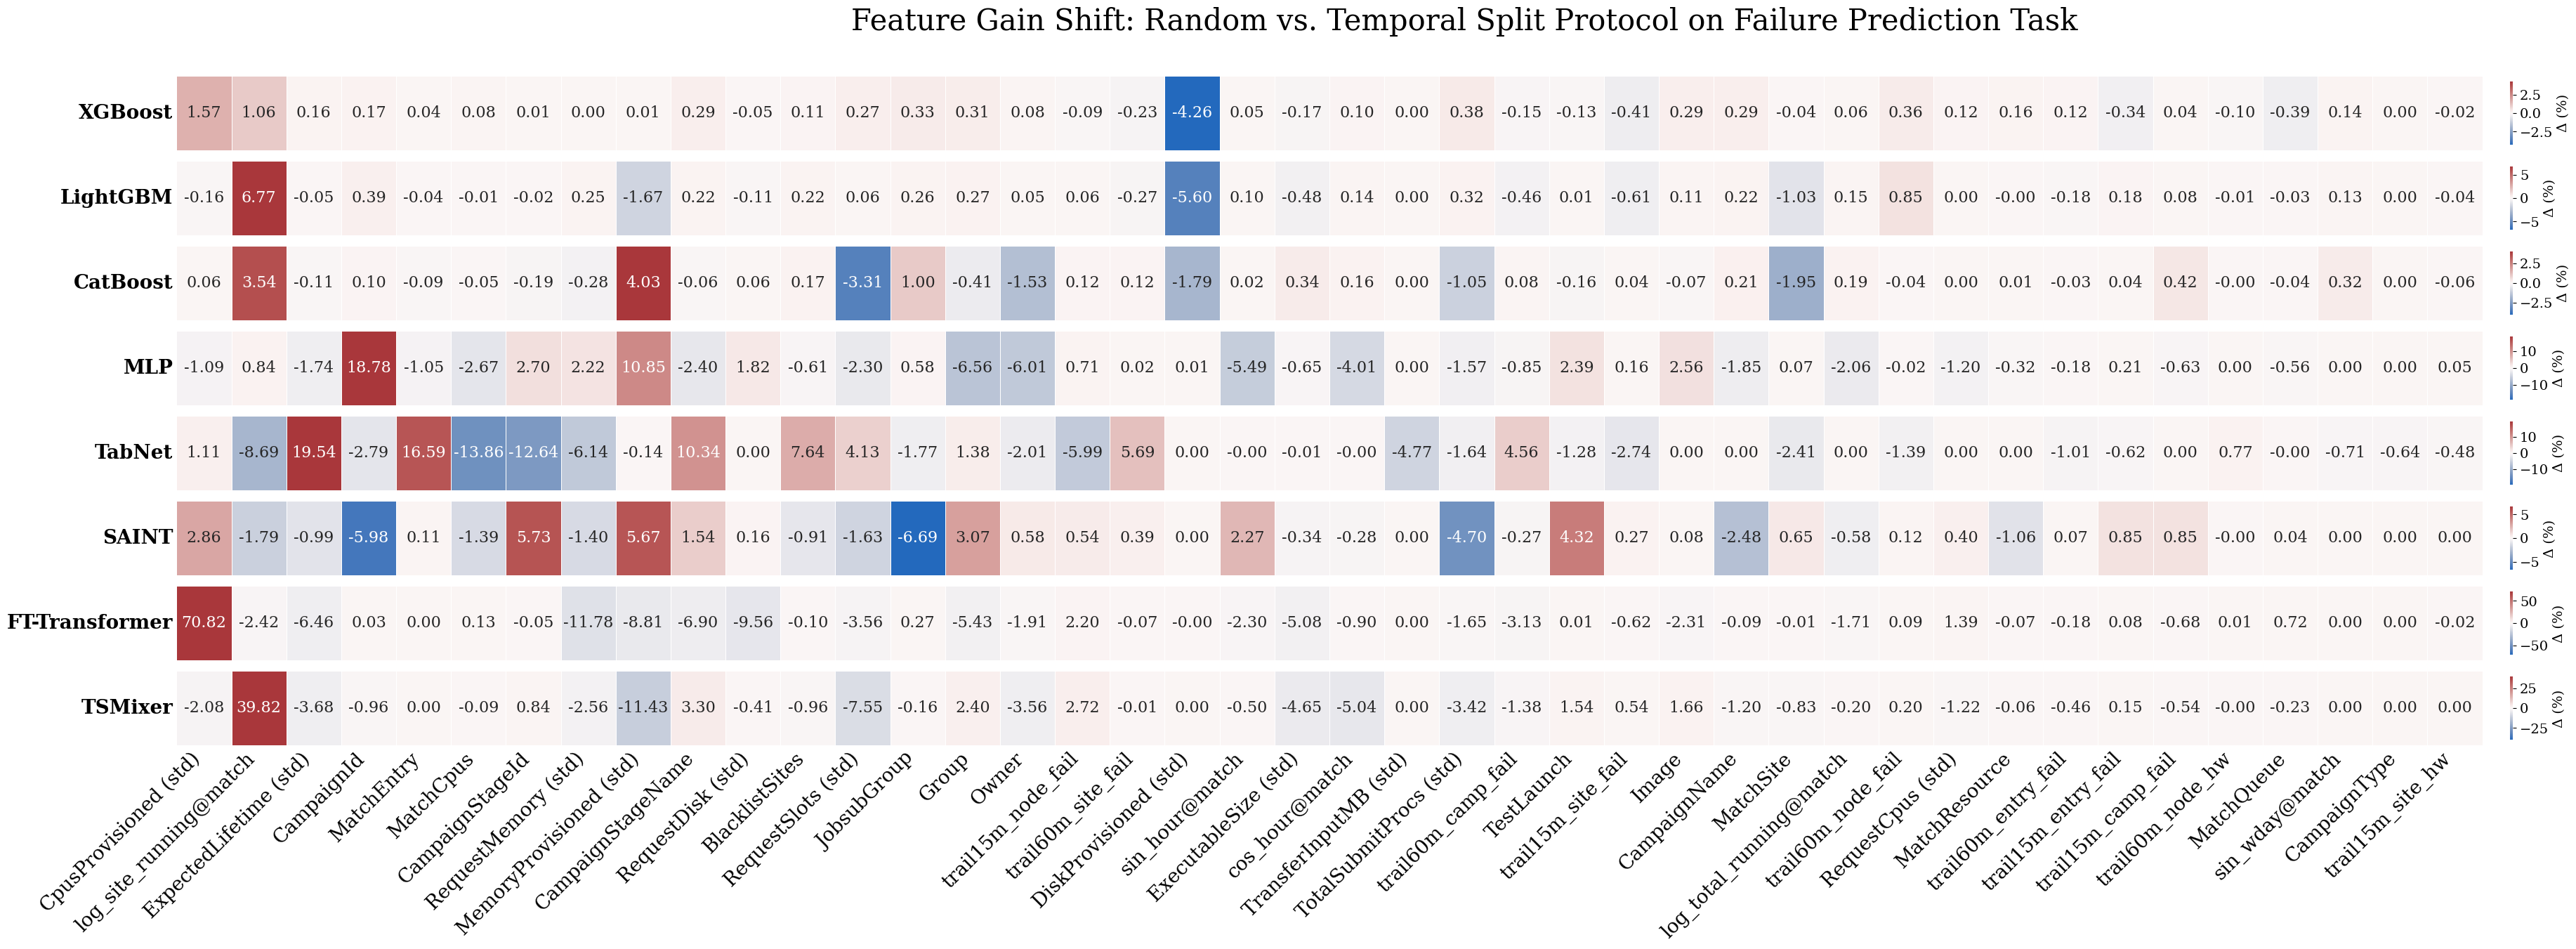

In [56]:
import eval.helper
importlib.reload(eval.helper)
from eval.helper import imp_diff_heatmap

imp_diff_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
)

### Failure prediction results (random split vs. temporal)

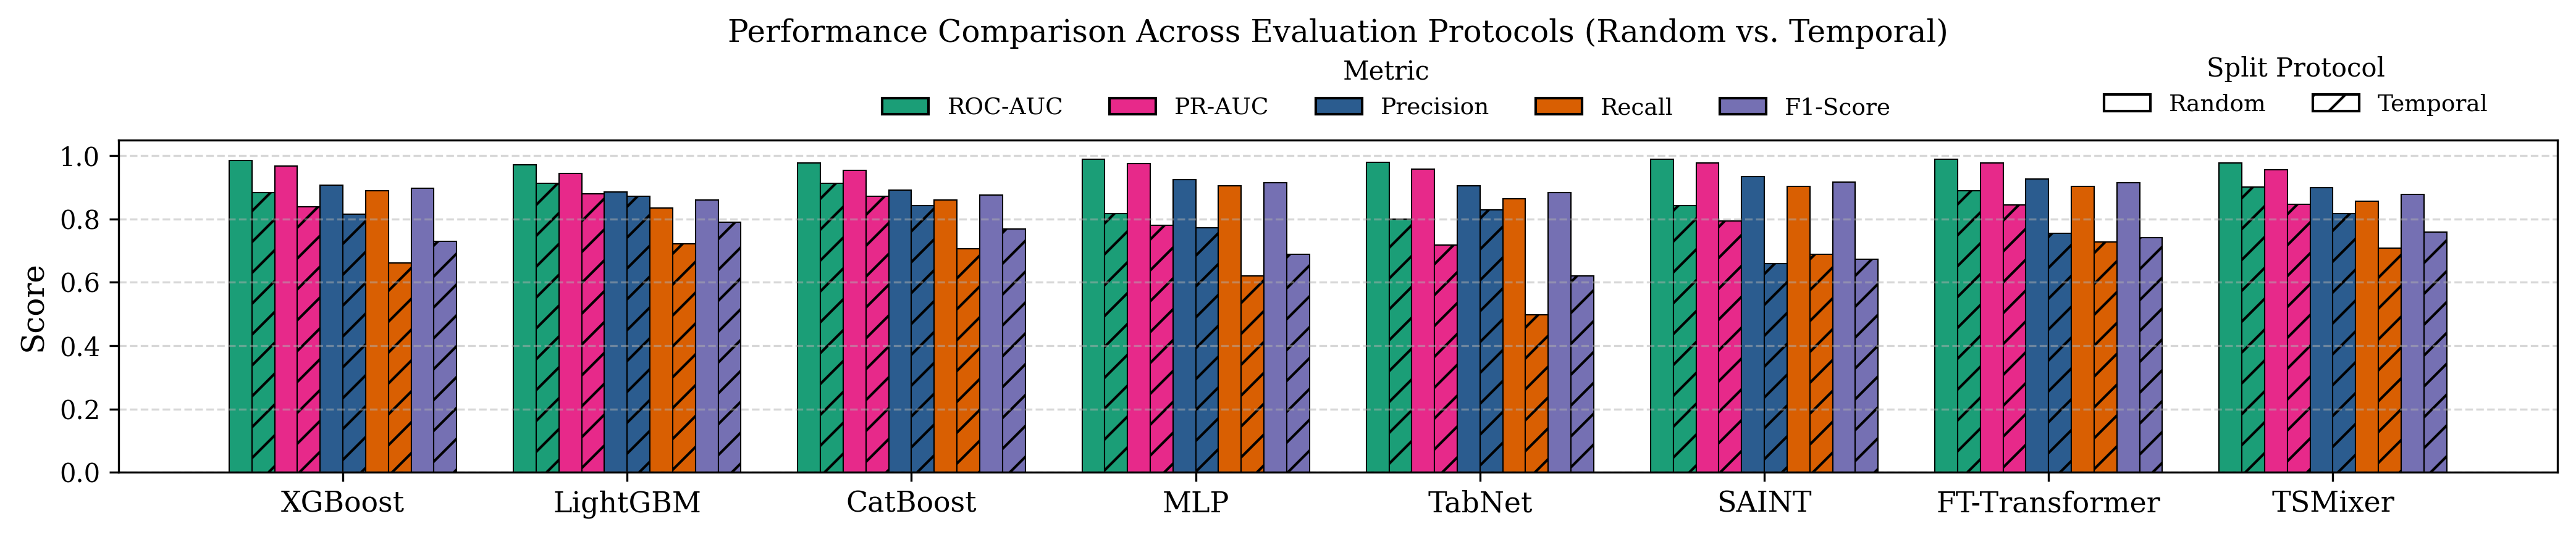

Saved plots to:
  - /opt/nfs/home/amaustin/Research/fife-batch-logs/scripts/protocol_ablation_summary.pdf
  - /opt/nfs/home/amaustin/Research/fife-batch-logs/scripts/protocol_ablation_summary.png


In [ ]:
import json
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

notebook_dir = os.getcwd()
input_path = os.path.join(notebook_dir, "output/protocol_eval_results.json")
with open(input_path, "r") as f:
    results = json.load(f)

models = results["models"]
roc_r, pr_r, prec_r, rec_r, f1_r = (
    results["roc_auc_r"],
    results["pr_auc_r"],
    results["prec_r"],
    results["rec_r"],
    results["f1_r"],
)
roc_t, pr_t, prec_t, rec_t, f1_t = (
    results["roc_auc_t"],
    results["pr_auc_t"],
    results["prec_t"],
    results["rec_t"],
    results["f1_t"],
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "figure.autolayout": True,
    }
)

fig, ax = plt.subplots(figsize=(14, 3), dpi=300)
x = np.arange(len(models))

# 10 bars per model (5 metrics x 2 splits) -> reduce width to fit group cleanly
w = 0.08

c_roc = "#1b9e77"
c_pr = "#e7298a"
c_prec = "#2b5c8f"
c_rec = "#d95f02"
c_f1 = "#7570b3"

hatch_random = ""
hatch_temporal = "//"

# Plot all 10 bars with distinct sequential offsets from x - 4.5*w to x + 4.5*w
ax.bar(
    x - 4.5 * w,
    roc_r,
    w,
    color=c_roc,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_random,
)
ax.bar(
    x - 3.5 * w,
    roc_t,
    w,
    color=c_roc,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_temporal,
)

ax.bar(
    x - 2.5 * w,
    pr_r,
    w,
    color=c_pr,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_random,
)
ax.bar(
    x - 1.5 * w,
    pr_t,
    w,
    color=c_pr,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_temporal,
)

ax.bar(
    x - 0.5 * w,
    prec_r,
    w,
    color=c_prec,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_random,
)
ax.bar(
    x + 0.5 * w,
    prec_t,
    w,
    color=c_prec,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_temporal,
)

ax.bar(
    x + 1.5 * w,
    rec_r,
    w,
    color=c_rec,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_random,
)
ax.bar(
    x + 2.5 * w,
    rec_t,
    w,
    color=c_rec,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_temporal,
)

ax.bar(
    x + 3.5 * w,
    f1_r,
    w,
    color=c_f1,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_random,
)
ax.bar(
    x + 4.5 * w,
    f1_t,
    w,
    color=c_f1,
    edgecolor="black",
    linewidth=0.5,
    hatch=hatch_temporal,
)

ax.set_ylabel("Score")
# Increased title padding to create space for legends underneath
ax.set_title(
    "Performance Comparison Across Evaluation Protocols (Random vs. Temporal)",
    pad=38,
)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=0, ha="center")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Dual legends for metrics (color) and splits (texture)
legend_metrics = [
    Patch(facecolor=c_roc, edgecolor="black", label="ROC-AUC"),
    Patch(facecolor=c_pr, edgecolor="black", label="PR-AUC"),
    Patch(facecolor=c_prec, edgecolor="black", label="Precision"),
    Patch(facecolor=c_rec, edgecolor="black", label="Recall"),
    Patch(facecolor=c_f1, edgecolor="black", label="F1-Score"),
]
legend_splits = [
    Patch(facecolor="white", edgecolor="black", label="Random"),
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch="//",
        label="Temporal",
    ),
]

leg1 = ax.legend(
    handles=legend_metrics,
    title="Metric",
    loc="lower center",
    bbox_to_anchor=(0.52, 1),
    ncol=5,
    frameon=True,
    facecolor="white",
    edgecolor="none",
)

ax.add_artist(leg1)
ax.legend(
    handles=legend_splits,
    title="Split Protocol",
    loc="lower right",
    bbox_to_anchor=(0.98, 1.01),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="none",
)

plt.tight_layout()

pdf_path = os.path.join(notebook_dir, "output/protocol_ablation_summary.pdf")
png_path = os.path.join(notebook_dir, "output/protocol_ablation_summary.png")

plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved plots to:\n  - {pdf_path}\n  - {png_path}")

### E1.5: Feature Ablation on Failed task (temporal split) 
`base -> +cyclical -> +campaign type -> +trailing site/campaign/node status` 

### E2: Queue wait time regression at submit time (temporal split)
See wait_time_regression.ipynb

### E3: Fault-attribution 
- 2-way (Hardware vs Payload)

### Figures